In [1]:
#Sorting through to get only raw data and transcriptions for 2nd session
import os
import pandas as pd

base_path = "extracted_files/screenreads"

sessions = []

for folder in os.listdir(base_path):
    
    session_path = os.path.join(base_path, folder)
    
    if os.path.isdir(session_path):
        
        for file in os.listdir(session_path):
            
            if "Session" in file and file.endswith(".csv"):
                
                file_path = os.path.join(session_path, file)
                
                try:
                    df = pd.read_csv(file_path, sep=None, engine="python")
                    df["SessionFolder"] = folder
                    sessions.append(df)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")


sessions_df = pd.concat(sessions, ignore_index=True)

In [2]:
# Check column names first!
print(sessions_df.columns)

session_info = sessions_df.groupby("SessionFolder").agg({
    "UserId": "first",
    "BookId": "first"
}).reset_index()

Index(['﻿Id', 'UserId', 'BookId', 'BookTitle', 'Font', 'FirstPage', 'LastPage',
       'Duration', 'Language', 'LIX', 'BookVersion', 'SessionFolder'],
      dtype='object')


In [3]:
# Sort (IMPORTANT: assumes folder order reflects time)
session_info = session_info.sort_values(["UserId", "SessionFolder"])

session_info["SessionOrder"] = session_info.groupby("UserId").cumcount() + 1

# Keep only 2nd sessions
second_sessions = session_info[session_info["SessionOrder"] == 2]

print("Number of second sessions:", len(second_sessions))

Number of second sessions: 60


In [4]:
import json

overview = []

for _, row in second_sessions.iterrows():
    
    folder = row["SessionFolder"]
    session_path = os.path.join(base_path, folder)
    
    files = os.listdir(session_path)
    
    for file in files:
        
        file_path = os.path.join(session_path, file)
        
        # ---- TARGET FILES ----
        if (
            "ScanPath" in file or
            "Layout" in file or
            "Session" in file or
            file == "matches_timeline.csv"
        ):
            
            # CSV files
            try:
                df = pd.read_csv(file_path, nrows=5, sep=None, engine="python", on_bad_lines="skip")
                columns = list(df.columns)
            except:
                columns = ["ERROR"]
            
            overview.append({
                "UserId": row["UserId"],
                "SessionFolder": folder,
                "File": file,
                "Type": "CSV",
                "Columns": ", ".join(columns)
            })
        
        # ---- JSON ----
        elif file == "transcriptions.json":
            
            try:
                with open(file_path, "r") as f:
                    data = json.load(f)
                
                if isinstance(data, dict):
                    keys = list(data.keys())
                elif isinstance(data, list) and len(data) > 0:
                    if isinstance(data[0], dict):
                        keys = list(data[0].keys())
                    else:
                        keys = ["List"]
                else:
                    keys = ["Unknown"]
            
            except:
                keys = ["ERROR"]
            
            overview.append({
                "UserId": row["UserId"],
                "SessionFolder": folder,
                "File": file,
                "Type": "JSON",
                "Columns": ", ".join(keys)
            })

In [5]:
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [6]:
overview_df = pd.DataFrame(overview)

# Save to Excel (recommended)
overview_df.to_excel("second_session_file_overview.xlsx", index=False)

# Optional CSV
overview_df.to_csv("second_session_file_overview.csv", index=False)

In [7]:
# Filter so that we only have sessions with the same book 
book_counts = second_sessions["BookId"].value_counts()

print(book_counts)

majority_book = book_counts.idxmax()

print("Majority book:", majority_book)

filtered_second_sessions = second_sessions[
    second_sessions["BookId"] == majority_book
]

print("Remaining sessions:", len(filtered_second_sessions))

valid_users = filtered_second_sessions["UserId"].unique()

print("Number of users kept:", len(valid_users))

filtered_df = sessions_df[sessions_df["UserId"].isin(valid_users)]

BookId
56    55
59     2
58     2
74     1
Name: count, dtype: int64
Majority book: 56
Remaining sessions: 55
Number of users kept: 55


In [8]:
#Check
print(filtered_second_sessions["BookId"].value_counts())

BookId
56    55
Name: count, dtype: int64


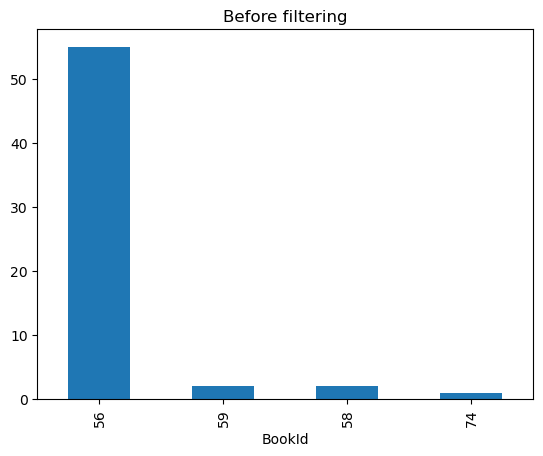

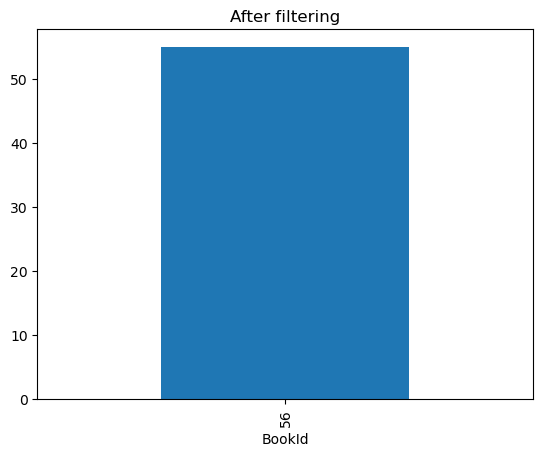

In [9]:
# Filtering vizualisations
import matplotlib.pyplot as plt

second_sessions["BookId"].value_counts().plot(kind="bar", title="Before filtering")
plt.show()

filtered_second_sessions["BookId"].value_counts().plot(kind="bar", title="After filtering")
plt.show()

In [10]:
print(filtered_df.columns.tolist())

['\ufeffId', 'UserId', 'BookId', 'BookTitle', 'Font', 'FirstPage', 'LastPage', 'Duration', 'Language', 'LIX', 'BookVersion', 'SessionFolder']


In [11]:
print(filtered_second_sessions.head())
print(filtered_second_sessions.columns)

   SessionFolder  UserId  BookId  SessionOrder
17          3541     199      56             2
20          3544     200      56             2
23          3547     201      56             2
27          3551     202      56             2
29          3554     203      56             2
Index(['SessionFolder', 'UserId', 'BookId', 'SessionOrder'], dtype='object')


In [12]:
#NEW!!

In [13]:
import os
import pandas as pd
import numpy as np

base_path = "extracted_files/screenreads"

#TABLE 1: All students, all sessions, before filtering
print("=" * 70)
print("TABLE 1: ALL SESSIONS BEFORE FILTERING")
print("=" * 70)

all_records = []

for folder in sorted(os.listdir(base_path)):
    session_path = os.path.join(base_path, folder)
    if not os.path.isdir(session_path):
        continue

    session_csv = next(
        (pd.read_csv(os.path.join(session_path, f), sep=None,
                     engine="python", on_bad_lines="skip")
         for f in os.listdir(session_path)
         if "Session" in f and f.endswith(".csv")),
        None
    )

    if session_csv is None or session_csv.empty:
        continue

    user_id  = session_csv["UserId"].iloc[0]
    book_id  = session_csv["BookId"].iloc[0]
    duration = session_csv["Duration"].iloc[0] \
               if "Duration" in session_csv.columns else np.nan

    files = os.listdir(session_path)

    record = {
        "UserId":               user_id,
        "SessionFolder":        folder,
        "BookId":               book_id,
        "Duration (s)":         round(duration, 1) \
                                if not np.isnan(duration) else "-",
        "SessionOrder":         None,   # filled below
        "Session CSV":          "Yes" if any("Session" in f
                                and f.endswith(".csv") for f in files)
                                else "No",
        "ScanPath CSV":         "Yes" if any("ScanPath" in f
                                and f.endswith(".csv") for f in files)
                                else "No",
        "Layout CSV":           "Yes" if any("Layout" in f
                                and f.endswith(".csv") for f in files)
                                else "No",
        "matches_timeline CSV": "Yes" if "matches_timeline.csv"
                                in files else "No",
        "transcriptions JSON":  "Yes" if "transcriptions.json"
                                in files else "No",
    }
    all_records.append(record)

table1_df = pd.DataFrame(all_records).sort_values(
    ["UserId", "SessionFolder"]
)
table1_df["SessionOrder"] = table1_df.groupby(
    "UserId"
).cumcount() + 1

# Print Table 1
print(f"\nTotal sessions:  {len(table1_df)}")
print(f"Unique students: {table1_df['UserId'].nunique()}")
print(f"Unique books:    {table1_df['BookId'].nunique()}")
print()
print(table1_df.to_string(index=False))

# File availability summary
print("\n--- File availability across all sessions ---")
file_cols = ["Session CSV", "ScanPath CSV", "Layout CSV",
             "matches_timeline CSV", "transcriptions JSON"]
for col in file_cols:
    n = (table1_df[col] == "Yes").sum()
    pct = n / len(table1_df) * 100
    print(f"  {col:<25}: {n}/{len(table1_df)} ({pct:.1f}%)")

table1_df.to_excel("methods_table1_all_sessions.xlsx",
                    index=False, engine="openpyxl")
print("\nSaved: methods_table1_all_sessions.xlsx")


# FILTERING SUMMARY TABLE
print("\n" + "=" * 70)
print("FILTERING STEPS SUMMARY")
print("=" * 70)

total_sessions  = len(table1_df)
total_students  = table1_df["UserId"].nunique()
second_sessions_n = len(table1_df[table1_df["SessionOrder"] == 2])
same_book_n     = len(filtered_second_sessions)
final_n         = len(filtered_second_sessions)

summary = pd.DataFrame([
    {"Step": "1. All recorded sessions",
     "N sessions": total_sessions,
     "N students": total_students,
     "Reason for exclusion": "-"},
    {"Step": "2. Second sessions only",
     "N sessions": second_sessions_n,
     "N students": second_sessions_n,
     "Reason for exclusion": "First sessions excluded"},
    {"Step": "3. Same book filter (BookId=56)",
     "N sessions": same_book_n,
     "N students": same_book_n,
     "Reason for exclusion": "Students reading different books excluded"},
    {"Step": "4. Final analytical sample (same book)",
     "N sessions": final_n,
     "N students": final_n,
     "Reason for exclusion": "-"},
])

print()
print(summary.to_string(index=False))
summary.to_excel("methods_table_filtering_steps.xlsx",
                  index=False, engine="openpyxl")
print("\nSaved: methods_table_filtering_steps.xlsx")



TABLE 1: ALL SESSIONS BEFORE FILTERING

Total sessions:  189
Unique students: 77
Unique books:    6

 UserId SessionFolder  BookId  Duration (s)  SessionOrder Session CSV ScanPath CSV Layout CSV matches_timeline CSV transcriptions JSON
    181          3523      98          67.7             1         Yes          Yes        Yes                  Yes                 Yes
    182          3524      56         184.7             1         Yes          Yes        Yes                  Yes                 Yes
    183          3525      58         140.6             1         Yes          Yes        Yes                  Yes                 Yes
    184          3526      98         109.3             1         Yes          Yes        Yes                  Yes                 Yes
    185          3527      56         190.2             1         Yes          Yes        Yes                  Yes                 Yes
    186          3528      58         130.1             1         Yes          Yes       

In [14]:
!pip install openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [15]:
# STEP 1: Load all session CSV files from the screenreads folder

import os
import json
import pandas as pd

base_path = "extracted_files/screenreads"

sessions = []

for folder in os.listdir(base_path):
    session_path = os.path.join(base_path, folder)

    if os.path.isdir(session_path):
        for file in os.listdir(session_path):
            if "Session" in file and file.endswith(".csv"):
                file_path = os.path.join(session_path, file)
                try:
                    df = pd.read_csv(file_path, sep=None, engine="python")
                    df["SessionFolder"] = folder
                    sessions.append(df)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")

sessions_df = pd.concat(sessions, ignore_index=True)
print("Columns:", sessions_df.columns.tolist())


# STEP 2: Identify each user's 2nd session by folder sort order
session_info = sessions_df.groupby("SessionFolder").agg(
    UserId=("UserId", "first"),
    BookId=("BookId", "first")
).reset_index()

# Sort by UserId then folder name (folder name reflects chronological order)
session_info = session_info.sort_values(["UserId", "SessionFolder"])
session_info["SessionOrder"] = session_info.groupby("UserId").cumcount() + 1

second_sessions = session_info[session_info["SessionOrder"] == 2].copy()
print(f"Number of second sessions: {len(second_sessions)}")



# STEP 3: Filter to the most common book (majority book)
book_counts = second_sessions["BookId"].value_counts()
print("Book counts:\n", book_counts)

majority_book = book_counts.idxmax()
print(f"Majority book: {majority_book}")

filtered_second_sessions = second_sessions[second_sessions["BookId"] == majority_book].copy()
print(f"Remaining sessions after book filter: {len(filtered_second_sessions)}")

valid_users = filtered_second_sessions["UserId"].unique()
print(f"Number of users kept: {len(valid_users)}")



# STEP 4: Build a file overview for the filtered sessions only
overview = []

for _, row in filtered_second_sessions.iterrows(): 
    folder = row["SessionFolder"]
    session_path = os.path.join(base_path, folder)

    if not os.path.isdir(session_path):
        continue

    for file in os.listdir(session_path):
        file_path = os.path.join(session_path, file)

        # Target CSV files
        if (
            "ScanPath" in file or
            "Layout" in file or
            "Session" in file or
            file == "matches_timeline.csv"
        ) and file.endswith(".csv"):

            try:
                df = pd.read_csv(file_path, nrows=5, sep=None, engine="python", on_bad_lines="skip")
                columns = list(df.columns)
            except Exception:
                columns = ["ERROR"]

            overview.append({
                "UserId": row["UserId"],
                "SessionFolder": folder,
                "File": file,
                "Type": "CSV",
                "Columns": ", ".join(columns)
            })

        # Transcription JSON files
        elif file == "transcriptions.json":
            try:
                with open(file_path, "r") as f:
                    data = json.load(f)

                if isinstance(data, dict):
                    keys = list(data.keys())
                elif isinstance(data, list) and len(data) > 0:
                    keys = list(data[0].keys()) if isinstance(data[0], dict) else ["List"]
                else:
                    keys = ["Unknown"]
            except Exception:
                keys = ["ERROR"]

            overview.append({
                "UserId": row["UserId"],
                "SessionFolder": folder,
                "File": file,
                "Type": "JSON",
                "Columns": ", ".join(keys)
            })

overview_df = pd.DataFrame(overview)
overview_df.to_excel("second_session_file_overview.xlsx", index=False)
overview_df.to_csv("second_session_file_overview.csv", index=False)
print(f"Overview saved: {len(overview_df)} file entries across {len(valid_users)} users")



# STEP 5: Filter the full sessions dataframe to valid users only
filtered_df = sessions_df[sessions_df["UserId"].isin(valid_users)].copy()
print(f"Rows in filtered dataset: {len(filtered_df)}")

Columns: ['\ufeffId', 'UserId', 'BookId', 'BookTitle', 'Font', 'FirstPage', 'LastPage', 'Duration', 'Language', 'LIX', 'BookVersion', 'SessionFolder']
Number of second sessions: 60
Book counts:
 BookId
56    55
59     2
58     2
74     1
Name: count, dtype: int64
Majority book: 56
Remaining sessions after book filter: 55
Number of users kept: 55
Overview saved: 253 file entries across 55 users
Rows in filtered dataset: 162


In [16]:
# BOOK 56 TRANSCRIPT 
print("\n" + "=" * 70)
print("BOOK 56 TRANSCRIPT (from Layout file)")
print("=" * 70)

# Use the first session folder for a student who read book 56
book56_folder = filtered_second_sessions["SessionFolder"].iloc[0]
book56_spath  = os.path.join(base_path, book56_folder)

layout_book56 = next(
    (pd.read_csv(os.path.join(book56_spath, f), sep=None,
                 engine="python", on_bad_lines="skip")
     for f in os.listdir(book56_spath)
     if "Layout" in f and f.endswith(".csv")),
    None
)

if layout_book56 is not None:
    # Verify it is book 56
    if "BookId" in layout_book56.columns:
        book_id_check = layout_book56["BookId"].iloc[0]
        print(f"\nBookId confirmed: {book_id_check}")

    # Reconstruct the full text page by page, line by line
    print("\n--- Full text of Book 56 ---\n")

    if all(c in layout_book56.columns for c in
           ["Page", "PageLineIndex", "LineWordIndex", "WordRaw"]):

        # Sort by page, line, word position
        text_df = layout_book56.sort_values(
            ["Page", "PageLineIndex", "LineWordIndex"]
        )

        current_page = None
        current_line = None
        line_buffer  = []

        for _, word_row in text_df.iterrows():
            page = word_row["Page"]
            line = word_row["PageLineIndex"]
            word = str(word_row["WordRaw"])

            # New page
            if page != current_page:
                if line_buffer:
                    print(" ".join(line_buffer))
                line_buffer   = []
                current_page  = page
                current_line  = line
                print(f"\n--- Page {int(page)} ---")

            # New line
            elif line != current_line:
                if line_buffer:
                    print(" ".join(line_buffer))
                line_buffer  = []
                current_line = line

            line_buffer.append(word)

        # Print last line
        if line_buffer:
            print(" ".join(line_buffer))

    else:
        # Fallback: just print words in order
        print("(Column structure differs — printing words in order)\n")
        words = layout_book56["WordRaw"].tolist()
        chunk_size = 12
        for i in range(0, len(words), chunk_size):
            print(" ".join(str(w) for w in words[i:i+chunk_size]))

    print(f"\nTotal words in book: {len(layout_book56)}")
    print(f"Total pages: {layout_book56['Page'].nunique()
          if 'Page' in layout_book56.columns else 'unknown'}")

else:
    print("Layout file not found for Book 56.")


BOOK 56 TRANSCRIPT (from Layout file)

--- Full text of Book 56 ---


--- Page 1 ---
Kapitel 1
Tobias suser hen til posthuset. Bag på
cyklen ligger en pakke. Han sætter
cyklen og tager pakken under armen og
går op ad trappen.
“Hej, Tobias,” råber Simone. “Hvad skal
du?”

--- Page 2 ---
“Jeg skal sende fars pakke,” siger han.
“Går du med?”
“Kan du ikke selv gøre det?” siger
Simone.
“Jo, men gå nu med,” siger Tobias.
Han vil godt have Simone med.

--- Page 3 ---
Hun er to år ældre end ham og er mere
vant til at sende pakker og den slags
ting.
“Okay, lillebror,” siger Simone. “Så går
jeg med.”
De følges ind på posthuset.

--- Page 4 ---
Tobias tager et nummer og venter på,
det bliver hans tur. Der er heldigvis ikke
ret mange før ham.
Mens Simone venter, går hun rundt og
kigger på kort i stativerne.
Efter nogle minutter bliver det Tobias’
tur.

--- Page 5 ---
Han lægger pakken på disken sammen
med den seddel, hans far har udfyldt.
Samtidig lyder et højt brag lige bag
ham. Et stativ bliver

In [17]:
# FEATURE ENGINEERING

In [18]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 185.8 MB/s  0:00:00

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [19]:

# STAGE 1: Feature engineering — one row per student

import os
import json
import numpy as np
import pandas as pd

base_path = "extracted_files/screenreads"

records = []

for _, row in filtered_second_sessions.iterrows():
    uid    = row["UserId"]
    folder = row["SessionFolder"]
    spath  = os.path.join(base_path, folder)

    # helpers 
    def read_csv(name, **kw):
        p = os.path.join(spath, name)
        if os.path.exists(p):
            return pd.read_csv(p, sep=None, engine="python",
                               on_bad_lines="skip", **kw)
        return None

    # load files 
    scanpath = next(
        (read_csv(f) for f in os.listdir(spath) if "ScanPath" in f and f.endswith(".csv")),
        None
    )
    timeline = read_csv("matches_timeline.csv")
    session_csv = next(
        (read_csv(f) for f in os.listdir(spath) if "Session" in f and f.endswith(".csv")),
        None
    )

    feat = {"UserId": uid}

# EYE-TRACKING FEATURES
    if scanpath is not None and not scanpath.empty:
        words = scanpath[scanpath["HitType"] == 1].copy()

        # Use original IVTFixation labels from the recording software
        fixations = scanpath[scanpath["IVTFixation"].notna()]
        total_clusters = len(scanpath)

        feat["fixation_rate"] = (
            len(fixations) / total_clusters if total_clusters > 0 else np.nan
        )

        durations = (fixations["End"] - fixations["Start"]) * 1000
        feat["mean_fixation_dur_ms"] = (
            durations.mean() if len(durations) > 0 else np.nan
        )

        # CV of fixation duration — captures steady-eye vs active-eye
        # differences without adaptive thresholding
        feat["fixation_dur_cv"] = (
            durations.std() / durations.mean()
            if len(durations) > 1 and durations.mean() > 0 else np.nan
        )

        # Inter-fixation interval: rapid IFI = fluent, slow IFI = hesitant
        if len(fixations) > 1:
            fix_sorted = fixations.sort_values("Start")
            ifi = (fix_sorted["Start"].shift(-1) - fix_sorted["End"]) * 1000
            ifi = ifi.dropna()
            ifi = ifi[ifi >= 0]
            feat["mean_ifi_ms"] = ifi.mean() if len(ifi) > 0 else np.nan
        else:
            feat["mean_ifi_ms"] = np.nan

        # Regression rate
        if len(words) > 1:
            words = words.sort_values("Start").reset_index(drop=True)
            same_line = words["LineIndex"] == words["LineIndex"].shift(1)
            regressions = (
                same_line & (words["WordIndex"] < words["WordIndex"].shift(1))
            )
            feat["regression_rate"] = regressions.sum() / max(len(words) - 1, 1)
        else:
            feat["regression_rate"] = np.nan

        # Mean forward saccade length
        if len(words) > 1:
            same_line   = words["LineIndex"] == words["LineIndex"].shift(1)
            forward     = same_line & (words["WordIndex"] > words["WordIndex"].shift(1))
            sac_lengths = (words["WordIndex"] - words["WordIndex"].shift(1))[forward]
            feat["mean_forward_saccade"] = (
                sac_lengths.mean() if len(sac_lengths) > 0 else np.nan
            )
        else:
            feat["mean_forward_saccade"] = np.nan

        # Pupil size 
        for eye in ["PupilLeft", "PupilRight"]:
            if eye in scanpath.columns:
                feat[f"mean_{eye.lower()}"] = scanpath[eye].mean()

    # AUDIO / TRANSCRIPTION FEATURES 
    if timeline is not None and not timeline.empty:
        tl = timeline.copy()

        # Word accuracy: proportion of transcribed words that matched the book
        if "Matched" in tl.columns:
            feat["word_accuracy"] = tl["Matched"].mean()

        # Mean match score: quality of matches, not just binary
        if "MatchScore" in tl.columns:
            feat["mean_match_score"] = tl["MatchScore"].mean()

        # Silence rate: proportion of words spoken during silence segments
        if "SilenceContained" in tl.columns:
            feat["silence_rate"] = tl["SilenceContained"].mean()

        # Mean confidence from Whisper transcription
        if "confidence" in tl.columns:
            feat["mean_transcription_confidence"] = tl["confidence"].mean()

        # Proportion retranscribed: indicates unclear speech
        if "retranscribed" in tl.columns:
            feat["retranscription_rate"] = (tl["retranscribed"] == 1.0).mean()

    # READING SPEED FEATURES 
    if session_csv is not None and not session_csv.empty:
        sess = session_csv.iloc[0]

        duration_s = sess.get("Duration", np.nan)
        feat["reading_duration_s"] = duration_s

        # Words per minute: need total word count
        # Use timeline row count as a proxy for words attempted
        if timeline is not None and not timeline.empty and not np.isnan(duration_s):
            n_words = timeline["WordCleanBook"].notna().sum()
            feat["words_per_minute"] = (n_words / duration_s * 60) if duration_s > 0 else np.nan
        else:
            feat["words_per_minute"] = np.nan

    records.append(feat)

features_df = pd.DataFrame(records).set_index("UserId")
# Clean up before re-running stages 2–4
features_df["mean_pupil"] = features_df[["mean_pupilleft", "mean_pupilright"]].mean(axis=1)

# Drop columns safely and ignores any that no longer exist
features_df = features_df.drop(
    columns=["mean_pupilleft", "mean_pupilright", "help_word_rate"],
    errors="ignore"  # <-- this is the fix
)

print(f"Feature matrix: {features_df.shape[0]} students × {features_df.shape[1]} features")
print(features_df.describe().round(2))

Feature matrix: 55 students × 14 features
       fixation_rate  mean_fixation_dur_ms  fixation_dur_cv  mean_ifi_ms  \
count          55.00                 55.00            55.00        55.00   
mean            0.57                 77.21             0.40        47.93   
std             0.16                  6.77             0.07        62.58   
min             0.13                 56.01             0.26        13.27   
25%             0.52                 75.81             0.36        19.44   
50%             0.62                 78.28             0.39        24.19   
75%             0.67                 81.78             0.42        40.24   
max             0.77                 89.63             0.61       338.78   

       regression_rate  mean_forward_saccade  word_accuracy  mean_match_score  \
count            55.00                 55.00          44.00             43.00   
mean              0.09                  1.54           0.73             97.25   
std               0.02        

In [20]:
# IMPUTATION AND SCALING

In [21]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 173.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [22]:
# STAGE 2: Impute missing values and standardise

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Check missingness before imputing: drop features missing >50% of students
missing_pct = features_df.isna().mean()
print("Missing % per feature:\n", missing_pct.sort_values(ascending=False).round(2))

keep_cols = missing_pct[missing_pct < 0.5].index.tolist()
features_clean = features_df[keep_cols].copy()

# Median imputation (robust to outliers vs mean)
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(features_clean)

# Z-score standardisation: essential before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

feature_names = keep_cols
print(f"Features retained: {len(feature_names)}")


Missing % per feature:
 mean_match_score                 0.22
words_per_minute                 0.20
mean_transcription_confidence    0.20
silence_rate                     0.20
word_accuracy                    0.20
retranscription_rate             0.20
mean_forward_saccade             0.00
regression_rate                  0.00
mean_ifi_ms                      0.00
fixation_dur_cv                  0.00
mean_fixation_dur_ms             0.00
fixation_rate                    0.00
reading_duration_s               0.00
mean_pupil                       0.00
dtype: float64
Features retained: 14


In [23]:
# PCA

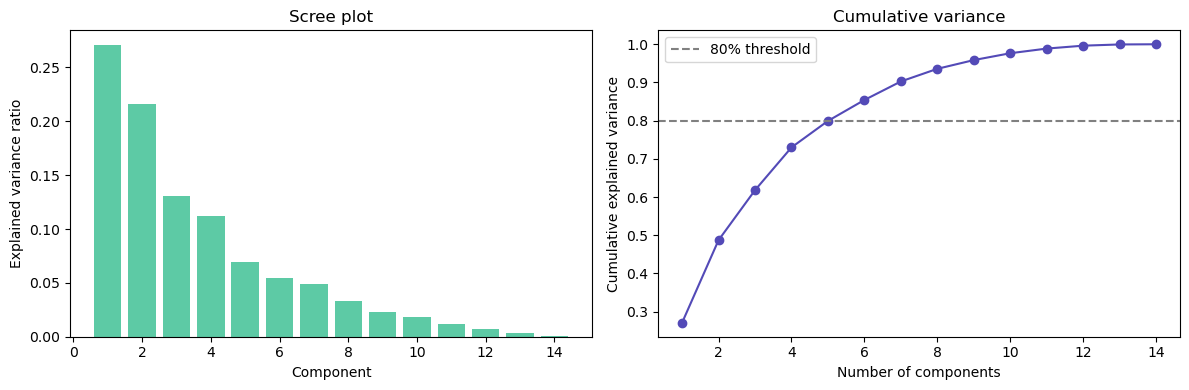

Components to reach 80% variance: 6

Top loadings per PC (|loading| > 0.3):

PC1:
fixation_rate           0.498
mean_fixation_dur_ms    0.484
fixation_dur_cv        -0.465
mean_ifi_ms            -0.407
Name: PC1, dtype: float64

PC2:
word_accuracy                    0.433
mean_transcription_confidence    0.376
retranscription_rate            -0.376
silence_rate                    -0.360
mean_match_score                 0.358
reading_duration_s              -0.321
Name: PC2, dtype: float64

PC3:
mean_forward_saccade             0.495
words_per_minute                 0.457
regression_rate                  0.424
mean_transcription_confidence   -0.335
Name: PC3, dtype: float64

PC4:
mean_match_score                 0.440
mean_pupil                      -0.438
mean_transcription_confidence    0.373
regression_rate                  0.364
silence_rate                     0.334
retranscription_rate             0.323
Name: PC4, dtype: float64

PC5:
mean_pupil              0.707
mean_forward_sac

In [24]:
# STAGE 3: PCA — choose components by explained variance

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Scree / elbow plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color="#5DCAA5")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot")

axes[1].plot(range(1, len(cumvar) + 1), cumvar, "o-", color="#534AB7")
axes[1].axhline(0.80, color="gray", linestyle="--", label="80% threshold")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative variance")
axes[1].legend()

plt.tight_layout()
plt.savefig("pca_scree.png", dpi=150)
plt.show()

# Auto-select components explaining >= 80% variance
n_components = int(np.argmax(cumvar >= 0.80)) + 1
print(f"Components to reach 80% variance: {n_components}")

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Loadings table: which original features drive each PC
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(n_components)]
)
print("\nTop loadings per PC (|loading| > 0.3):")
for col in loadings.columns:
    top = loadings[col][loadings[col].abs() > 0.3].sort_values(key=abs, ascending=False)
    print(f"\n{col}:\n{top.round(3)}")

In [25]:
# CLUSTERING

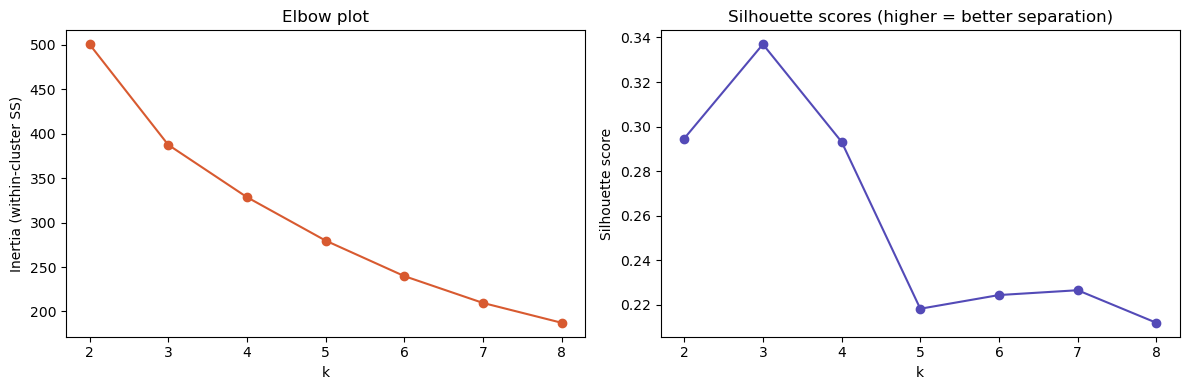


Cluster sizes:
0    37
1    10
2     8
Name: count, dtype: int64


In [26]:
# STAGE 4: K-means clustering — select k empirically

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, sil_scores = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

# Diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, "o-", color="#D85A30")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (within-cluster SS)")
axes[0].set_title("Elbow plot")

axes[1].plot(list(k_range), sil_scores, "o-", color="#534AB7")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette scores (higher = better separation)")

plt.tight_layout()
plt.savefig("cluster_selection.png", dpi=150)
plt.show()

# Chosen K
CHOSEN_K = 3  

km_final = KMeans(n_clusters=CHOSEN_K, n_init=100, random_state=42)
cluster_labels = km_final.fit_predict(X_pca)

features_clean["Cluster"] = cluster_labels
print(f"\nCluster sizes:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

In [27]:
# VALIDATION AND PROFILING

In [28]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Final silhouette score (k=3): 0.337


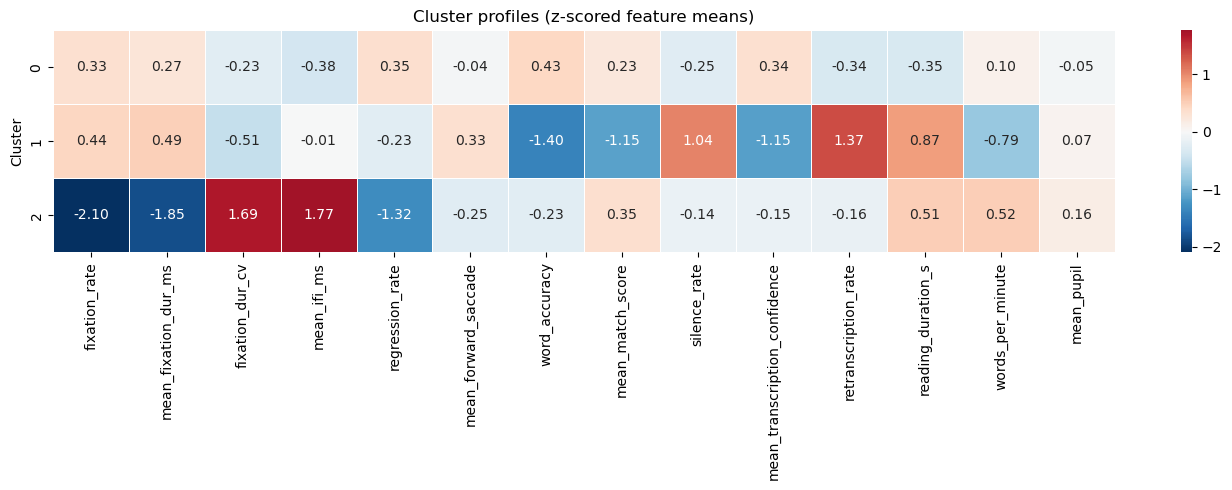

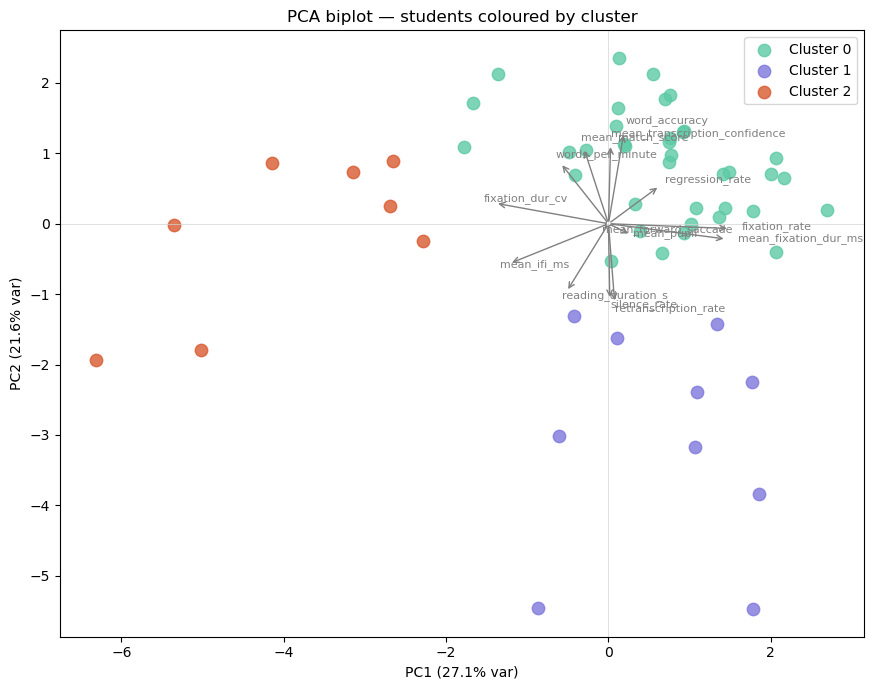

In [29]:
# STAGE 5: Profile clusters and produce diagnostic plots

import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

sil_final = silhouette_score(X_pca, cluster_labels)
print(f"Final silhouette score (k={CHOSEN_K}): {sil_final:.3f}")
# Rule of thumb: >0.5 = strong, 0.25–0.5 = moderate, <0.25 = weak structure

# Cluster means heatmap: on original scaled features
profile_df = pd.DataFrame(X_scaled, columns=feature_names,
                          index=features_clean.index)
profile_df["Cluster"] = cluster_labels
cluster_means = profile_df.groupby("Cluster")[feature_names].mean()

fig, ax = plt.subplots(figsize=(14, CHOSEN_K + 2))
sns.heatmap(cluster_means, cmap="RdBu_r", center=0, annot=True,
            fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Cluster profiles (z-scored feature means)")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig("cluster_heatmap.png", dpi=150)
plt.show()

# PCA biplot: PC1 vs PC2 with loading arrows
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#5DCAA5", "#7F77DD", "#D85A30", "#FAC775"][:CHOSEN_K]

for c in range(CHOSEN_K):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f"Cluster {c}", color=colors[c], s=80, alpha=0.8)

# Loading arrows for first 2 PCs
scale = 3
for i, feat in enumerate(feature_names):
    ax.annotate("", xy=(pca.components_[0, i] * scale,
                         pca.components_[1, i] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1))
    ax.text(pca.components_[0, i] * scale * 1.1,
            pca.components_[1, i] * scale * 1.1,
            feat, fontsize=8, color="gray")

ax.axhline(0, color="lightgray", lw=0.5)
ax.axvline(0, color="lightgray", lw=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA biplot — students coloured by cluster")
ax.legend()
plt.tight_layout()
plt.savefig("pca_biplot.png", dpi=150)
plt.show()

In [30]:
# GAUSSIAN MIXED MODELS

from sklearn.mixture import GaussianMixture

CHOSEN_K = 3

gmm_final = GaussianMixture(n_components=CHOSEN_K, n_init=20, random_state=42)
gmm_final.fit(X_pca)
cluster_labels = gmm_final.predict(X_pca)

# Soft probabilities — useful to flag borderline students
cluster_probs = gmm_final.predict_proba(X_pca)
prob_df = pd.DataFrame(cluster_probs,
                       index=features_clean.index,
                       columns=[f"P(Cluster {i})" for i in range(CHOSEN_K)])
prob_df["AssignedCluster"] = cluster_labels
prob_df["MaxProb"] = cluster_probs.max(axis=1)

# Flag students the model is uncertain about (max probability < 0.70)
borderline = prob_df[prob_df["MaxProb"] < 0.70]
print(f"Borderline students (uncertain assignment): {len(borderline)}")
print(borderline.round(2))

features_clean["Cluster"] = cluster_labels
print(f"\nCluster sizes:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

Borderline students (uncertain assignment): 0
Empty DataFrame
Columns: [P(Cluster 0), P(Cluster 1), P(Cluster 2), AssignedCluster, MaxProb]
Index: []

Cluster sizes:
0    39
1    12
2     4
Name: count, dtype: int64


In [31]:
# Confirm cluster identities with revised feature set
profile_df = pd.DataFrame(X_scaled, columns=feature_names,
                          index=features_clean.index)
profile_df["Cluster"] = cluster_labels
cluster_means = profile_df.groupby("Cluster")[feature_names].mean()

print("Cluster means for key identifying features:")
print(cluster_means[[
    "word_accuracy", 
    "fixation_rate",
    "fixation_dur_cv",
    "retranscription_rate"
]].round(2))

typical_cluster    = int(cluster_means["word_accuracy"].idxmax())
decoding_cluster   = int(cluster_means["retranscription_rate"].idxmax())
atypical_cluster = int([c for c in range(CHOSEN_K)
                          if c not in [typical_cluster, decoding_cluster]][0])

print(f"\nTypical cluster:    {typical_cluster}  n={(cluster_labels == typical_cluster).sum()}")
print(f"Decoding cluster:   {decoding_cluster}  n={(cluster_labels == decoding_cluster).sum()}")
print(f"Atypical cluster: {atypical_cluster}  n={(cluster_labels == atypical_cluster).sum()}")

Cluster means for key identifying features:
         word_accuracy  fixation_rate  fixation_dur_cv  retranscription_rate
Cluster                                                                     
0                 0.22           0.47            -0.36                 -0.17
1                 0.11          -1.62             1.39                 -0.29
2                -2.48           0.30            -0.67                  2.56

Typical cluster:    0  n=39
Decoding cluster:   2  n=4
Atypical cluster: 1  n=12


In [32]:
# CONFIDENCE DISTRIBUTION
print(f"Lowest confidence assignment: {prob_df['MaxProb'].min():.3f}")
print(f"Mean confidence: {prob_df['MaxProb'].mean():.3f}")
print(f"\nConfidence distribution:")
print(prob_df['MaxProb'].describe().round(3))

# Show the 5 least confidently assigned students regardless of threshold
print("\n5 most borderline students:")
print(prob_df.nsmallest(5, 'MaxProb').round(3))

Lowest confidence assignment: 0.756
Mean confidence: 0.989

Confidence distribution:
count    55.000
mean      0.989
std       0.042
min       0.756
25%       1.000
50%       1.000
75%       1.000
max       1.000
Name: MaxProb, dtype: float64

5 most borderline students:
        P(Cluster 0)  P(Cluster 1)  P(Cluster 2)  AssignedCluster  MaxProb
UserId                                                                    
220            0.756         0.244           0.0                0    0.756
228            0.192         0.808           0.0                1    0.808
245            0.956         0.044           0.0                0    0.956
209            0.966         0.034           0.0                0    0.966
249            0.982         0.018           0.0                0    0.982


In [33]:
# 6D DISTANCES 
from scipy.spatial.distance import cdist

# Cluster centroids in PCA space
centroids = np.array([X_pca[cluster_labels == k].mean(axis=0) 
                      for k in range(CHOSEN_K)])

# Distance from each student to their assigned centroid vs nearest other centroid
assigned_dist = np.array([
    np.linalg.norm(X_pca[i] - centroids[cluster_labels[i]])
    for i in range(len(X_pca))
])
nearest_other_dist = np.array([
    min(np.linalg.norm(X_pca[i] - centroids[k])
        for k in range(CHOSEN_K) if k != cluster_labels[i])
    for i in range(len(X_pca))
])

separation_ratio = nearest_other_dist / assigned_dist
print("Separation ratio (>1 means closer to own centroid than any other):")
print(pd.Series(separation_ratio).describe().round(2))

# Flag anyone where the ratio is close to 1 (genuinely borderline)
genuinely_borderline = np.where(separation_ratio < 1.5)[0]
print(f"\nStudents within 1.5x of another centroid: {len(genuinely_borderline)}")
if len(genuinely_borderline) > 0:
    print(features_clean.iloc[genuinely_borderline][["Cluster"]].join(
        pd.Series(separation_ratio[genuinely_borderline], 
                  name="separation_ratio",
                  index=features_clean.index[genuinely_borderline])
    ).round(2))

Separation ratio (>1 means closer to own centroid than any other):
count    55.00
mean      2.10
std       0.64
min       0.67
25%       1.55
50%       2.14
75%       2.46
max       3.37
dtype: float64

Students within 1.5x of another centroid: 11
        Cluster  separation_ratio
UserId                           
202           0              1.35
213           0              1.22
219           0              1.16
220           0              1.46
222           1              1.45
225           0              1.49
226           1              1.20
228           1              0.67
231           0              1.05
235           0              1.33
241           0              1.44


In [34]:
# EXPORT GROUP ASSIGNMENTS

In [35]:
# STAGE 6: Export final group assignments

cluster_names = {
    0: "Typical",
    1: "Atypical",
    2: "Decoding difficulty",
}

output = features_clean[["Cluster"]].copy()
output["ClusterLabel"] = output["Cluster"].map(cluster_names)
output = output.reset_index()  # brings UserId back as a column

output.to_csv("intervention_groups.csv", index=False, encoding="utf-8-sig")
print("\nExported intervention_groups.csv")
print(output.groupby("ClusterLabel")["UserId"].count())

# Add separation ratio to the output
sep_series = pd.Series(separation_ratio, 
                        index=features_clean.index, 
                        name="separation_ratio")

output = features_clean[["Cluster"]].copy()
output["ClusterLabel"] = output["Cluster"].map(cluster_names)
output["separation_ratio"] = sep_series.round(2)
output["needs_review"] = sep_series < 1.5
output = output.reset_index()

# Summary
print(f"Confidently assigned: {(~output['needs_review']).sum()}")
print(f"Flagged for review:   {output['needs_review'].sum()}")
print(f"\nFlagged students:\n")
print(output[output["needs_review"]][
    ["UserId", "ClusterLabel", "separation_ratio"]
].to_string(index=False))

output.to_csv("intervention_groups.csv", index=False, encoding="utf-8-sig")



Exported intervention_groups.csv
ClusterLabel
Atypical               12
Decoding difficulty     4
Typical                39
Name: UserId, dtype: int64
Confidently assigned: 44
Flagged for review:   11

Flagged students:

 UserId ClusterLabel  separation_ratio
    202      Typical              1.35
    213      Typical              1.22
    219      Typical              1.16
    220      Typical              1.46
    222     Atypical              1.45
    225      Typical              1.49
    226     Atypical              1.20
    228     Atypical              0.67
    231      Typical              1.05
    235      Typical              1.33
    241      Typical              1.44


In [36]:
#TABLE 2: Final sample after filtering (n=55)
print("\n" + "=" * 70)
print("TABLE 2: FINAL SAMPLE AFTER FILTERING (n=55)")
print("=" * 70)

final_records = []

for _, row in filtered_second_sessions.iterrows():
    uid    = row["UserId"]
    folder = row["SessionFolder"]
    spath  = os.path.join(base_path, folder)

    if not os.path.isdir(spath):
        continue

    files = os.listdir(spath)

    has_scanpath = any("ScanPath" in f and f.endswith(".csv")
                       for f in files)
    has_timeline = "matches_timeline.csv" in files
    has_layout   = any("Layout" in f and f.endswith(".csv")
                       for f in files)
    has_transc   = "transcriptions.json" in files

    in_cluster = uid in features_clean.index
    if in_cluster:
        cluster_int = cluster_labels[
            list(features_clean.index).index(uid)
        ]
        cluster_label = {
            typical_cluster:  "Typical",
            decoding_cluster: "Decoding difficulty",
            atypical_cluster: "Atypical fixation",
        }.get(cluster_int, "Unknown")
    else:
        cluster_label = "Excluded"

    sep_ratio = sep_series.get(uid, np.nan) \
                if uid in sep_series.index else np.nan

    final_records.append({
        "UserId":             uid,
        "ScanPath":           "Yes" if has_scanpath else "No",
        "matches_timeline":   "Yes" if has_timeline else "No",
        "Layout":             "Yes" if has_layout   else "No",
        "transcriptions":     "Yes" if has_transc   else "No",
        "ET features":        "Yes" if has_scanpath else "No",
        "Audio features":     "Yes" if has_timeline else "No",
        "Intervention group": cluster_label,
        "Separation ratio":   round(sep_ratio, 2) \
                              if not np.isnan(sep_ratio) else "—",
        "Needs review":       "Yes" if not np.isnan(sep_ratio)
                              and sep_ratio < 1.5 else "No",
    })

table2_df = pd.DataFrame(final_records).sort_values("UserId")

print(f"\nFinal sample: {len(table2_df)} students")
print()
print(table2_df.to_string(index=False))

# File availability summary
print("\n--- File availability in final sample ---")
avail_cols = ["ScanPath", "matches_timeline",
              "Layout", "transcriptions"]
for col in avail_cols:
    n = (table2_df[col] == "Yes").sum()
    pct = n / len(table2_df) * 100
    print(f"  {col:<25}: {n}/{len(table2_df)} ({pct:.1f}%)")

print("\n--- Intervention group distribution ---")
print(table2_df["Intervention group"].value_counts().to_string())

print("\n--- Students flagged for individual review ---")
review_list = table2_df[table2_df["Needs review"] == "Yes"]["UserId"].tolist()
print(f"  n={len(review_list)}: {review_list}")

table2_df.to_excel("methods_table2_final_sample.xlsx",
                    index=False, engine="openpyxl")
print("\nSaved: methods_table2_final_sample.xlsx")


TABLE 2: FINAL SAMPLE AFTER FILTERING (n=55)

Final sample: 55 students

 UserId ScanPath matches_timeline Layout transcriptions ET features Audio features  Intervention group  Separation ratio Needs review
    199      Yes              Yes    Yes            Yes         Yes            Yes             Typical              3.27           No
    200      Yes              Yes    Yes            Yes         Yes            Yes             Typical              3.04           No
    201      Yes              Yes    Yes            Yes         Yes            Yes Decoding difficulty              1.55           No
    202      Yes              Yes    Yes            Yes         Yes            Yes             Typical              1.35          Yes
    203      Yes              Yes    Yes            Yes         Yes            Yes             Typical              2.27           No
    204      Yes              Yes    Yes            Yes         Yes            Yes             Typical              3.16  

In [37]:
# SUB-CLUSTERS

In [38]:
# Sub-clustering diagnostics with revised features

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

pca_df = pd.DataFrame(X_pca, index=features_clean.index,
                      columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
pca_df["Cluster"] = cluster_labels

# Typical group (n=39) — PC2 is now the accuracy dimension
# PC3 is fluency/saccade
c_typ_idx = pca_df[pca_df["Cluster"] == typical_cluster].index
X_typ = pca_df.loc[c_typ_idx, ["PC2", "PC3"]].values

print(f"=== Typical group (n={len(c_typ_idx)}) ===")
for k in [2, 3]:
    gmm = GaussianMixture(n_components=k, n_init=20, random_state=42)
    labels = gmm.fit_predict(X_typ)
    sil = silhouette_score(X_typ, labels)
    bic = gmm.bic(X_typ)
    sizes = pd.Series(labels).value_counts().sort_index().tolist()
    print(f"  k={k}  silhouette={sil:.3f}  BIC={bic:.1f}  sizes={sizes}")

# Inconsistent fixation group (n=12) — PC1 is now the eye movement
# stability dimension, most relevant for this group
c_low_idx = pca_df[pca_df["Cluster"] == atypical_cluster].index
X_low = pca_df.loc[c_low_idx, ["PC1"]].values

print(f"\n=== Atypical group (n={len(c_low_idx)}) ===")
for k in [2, 3]:
    if len(c_low_idx) < k * 3:
        print(f"  k={k}  skipped — too few students")
        continue
    gmm = GaussianMixture(n_components=k, n_init=20, random_state=42)
    labels = gmm.fit_predict(X_low)
    sil = silhouette_score(X_low, labels) if k > 1 else None
    bic = gmm.bic(X_low)
    sizes = pd.Series(labels).value_counts().sort_index().tolist()
    print(f"  k={k}  silhouette={sil:.3f}  BIC={bic:.1f}  sizes={sizes}")

=== Typical group (n=39) ===
  k=2  silhouette=0.607  BIC=273.8  sizes=[1, 38]
  k=3  silhouette=0.451  BIC=278.9  sizes=[7, 1, 31]

=== Atypical group (n=12) ===
  k=2  silhouette=0.649  BIC=55.7  sizes=[8, 4]
  k=3  silhouette=0.513  BIC=50.9  sizes=[8, 1, 3]


In [39]:
# ADDITIONAL  STATISTICS

# STATISTICS 1: Feature reliability and PCA stability

from sklearn.decomposition import PCA
from sklearn.utils import resample
import numpy as np
import pandas as pd

# Inter-feature correlation within each PC dimension 
# For each PC, take the features with |loading| > 0.3, compute their average pairwise correlation
# High average r = features are measuring a coherent construct

print("=== Average inter-feature correlation per PC ===")
for pc_idx in range(X_pca.shape[1]):
    pc_name = f"PC{pc_idx + 1}"
    loadings_pc = loadings[pc_name]
    strong = loadings_pc[loadings_pc.abs() > 0.3].index.tolist()
    
    if len(strong) < 2:
        print(f"{pc_name}: only {len(strong)} strong loading(s), skipping")
        continue
    
    corr_matrix = pd.DataFrame(
        X_scaled, columns=feature_names
    )[strong].corr()
    
    # Average of off-diagonal correlations
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    avg_r = corr_matrix.where(mask).stack().mean()
    print(f"{pc_name} ({', '.join(strong)}): avg r = {avg_r:.3f}")

# Bootstrap PCA stability 
# Resample students with replacement 1000 times
# Refit PCA each time and check how stable the component loadings are
# High std = loadings are sensitive to which students are included

print("\n=== Bootstrap PCA loading stability (1000 iterations) ===")
n_boot = 1000
boot_loadings = []

for _ in range(n_boot):
    X_boot = resample(X_scaled, random_state=None)
    pca_boot = PCA(n_components=pca.n_components_)
    pca_boot.fit(X_boot)
    boot_loadings.append(pca_boot.components_)

boot_loadings = np.array(boot_loadings) 

# For each PC, report mean and std of each feature loading
for pc_idx in range(pca.n_components_):
    pc_name = f"PC{pc_idx + 1}"
    means = boot_loadings[:, pc_idx, :].mean(axis=0)
    stds  = boot_loadings[:, pc_idx, :].std(axis=0)
    
    stability_df = pd.DataFrame({
        "feature":      feature_names,
        "mean_loading": means,
        "std_loading":  stds,
        "cv":           np.abs(stds / np.where(np.abs(means) > 0.01, means, np.nan))
    }).set_index("feature")
    
    # Flag unstable loadings: CV > 0.5 means loading flips direction often
    strong = stability_df["mean_loading"].abs() > 0.3
    if strong.any():
        print(f"\n{pc_name} — strong loaders (|loading| > 0.3):")
        print(stability_df[strong][["mean_loading", "std_loading", "cv"]].round(3))


# STATISTICS 2: Between-cluster ANOVAs and effect sizes
from scipy import stats
import itertools

# Eta-squared: proportion of variance explained by cluster membership
# >0.01 = small, >0.06 = medium, >0.14 = large effect
def eta_squared(groups):
    grand_mean = np.concatenate(groups).mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total   = sum(((x - grand_mean)**2) for g in groups for x in g)
    return ss_between / ss_total if ss_total > 0 else np.nan

# Cohen's d for pairwise comparisons
def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else np.nan

profile_df = pd.DataFrame(X_scaled, columns=feature_names,
                          index=features_clean.index)
profile_df["Cluster"] = cluster_labels

cluster_ids  = sorted(profile_df["Cluster"].unique())
cluster_map  = {
    typical_cluster:    "Typical",
    decoding_cluster:   "Decoding",
    atypical_cluster: "Atypical",
}

print("=== One-way ANOVA and effect sizes per feature ===\n")
anova_results = []

for feat_name in feature_names:
    groups = [
        profile_df[profile_df["Cluster"] == c][feat_name].dropna().values
        for c in cluster_ids
    ]
    
    # Skip if any group = empty
    if any(len(g) == 0 for g in groups):
        continue
    
    f_stat, p_val = stats.f_oneway(*groups)
    eta2 = eta_squared(groups)
    
    anova_results.append({
        "feature":   feat_name,
        "F":         round(f_stat, 3),
        "p":         round(p_val, 4),
        "eta2":      round(eta2, 3),
        "sig":       "***" if p_val < 0.001 else "**" if p_val < 0.01 
                     else "*" if p_val < 0.05 else "ns"
    })

anova_df = pd.DataFrame(anova_results).sort_values("eta2", ascending=False)
print(anova_df.to_string(index=False))

# Pairwise post-hoc: Cohen's d for significant features
print("\n=== Pairwise Cohen's d (significant features only) ===\n")
sig_features = anova_df[anova_df["p"] < 0.05]["feature"].tolist()

posthoc_results = []
for feat_name in sig_features:
    for c1, c2 in itertools.combinations(cluster_ids, 2):
        g1 = profile_df[profile_df["Cluster"] == c1][feat_name].dropna().values
        g2 = profile_df[profile_df["Cluster"] == c2][feat_name].dropna().values
        d  = cohens_d(g1, g2)
        
        # Welch t-test for unequal group sizes
        t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
        
        posthoc_results.append({
            "feature":    feat_name,
            "group_1":    cluster_map[c1],
            "group_2":    cluster_map[c2],
            "cohen_d":    round(abs(d), 3),
            "p":          round(p_val, 4),
            "sig":        "***" if p_val < 0.001 else "**" if p_val < 0.01
                          else "*" if p_val < 0.05 else "ns",
            "magnitude":  "large" if abs(d) > 0.8 else "medium" if abs(d) > 0.5
                          else "small"
        })

posthoc_df = pd.DataFrame(posthoc_results).sort_values(
    ["feature", "cohen_d"], ascending=[True, False]
)
print(posthoc_df.to_string(index=False))

anova_df.to_excel("cluster_anova_results.xlsx", index=False, engine="openpyxl")
posthoc_df.to_excel("cluster_posthoc_results.xlsx", index=False, engine="openpyxl")
print("\nSaved: cluster_anova_results.xlsx, cluster_posthoc_results.xlsx")


# STATISTICS 3: Within-cluster consistency and outlier flagging
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv, LinAlgError

print("=== Within-cluster feature consistency ===\n")
consistency_results = []

for c in cluster_ids:
    mask      = profile_df["Cluster"] == c
    X_cluster = profile_df[mask][feature_names].values
    n         = len(X_cluster)
    
    # Mean pairwise cosine similarity within cluster
    # Higher = more homogeneous group
    from sklearn.metrics.pairwise import cosine_similarity
    sim_matrix = cosine_similarity(X_cluster)
    mask_upper = np.triu(np.ones(sim_matrix.shape), k=1).astype(bool)
    avg_sim    = sim_matrix[mask_upper].mean()
    
    consistency_results.append({
        "cluster":     cluster_map[c],
        "n":           n,
        "avg_cosine_similarity": round(avg_sim, 3),
    })
    print(f"Cluster '{cluster_map[c]}' (n={n}): "
          f"avg cosine similarity = {avg_sim:.3f}")

# Mahalanobis distance: flag outliers within each cluster 
# Did not show results: excluded 
print("\n=== Within-cluster outliers (Mahalanobis distance) ===\n")
outlier_flags = []

for c in cluster_ids:
    mask      = profile_df["Cluster"] == c
    idx       = profile_df[mask].index
    X_cluster = profile_df[mask][feature_names].values
    
    if len(X_cluster) < len(feature_names) + 2:
        print(f"Cluster '{cluster_map[c]}': too small for "
              f"Mahalanobis distance, skipping")
        continue
    
    try:
        cov     = np.cov(X_cluster.T)
        cov_inv = inv(cov)
        center  = X_cluster.mean(axis=0)
        
        distances = [
            mahalanobis(x, center, cov_inv) for x in X_cluster
        ]
        
        # Chi-squared threshold at p=0.001 with n_features degrees of freedom
        threshold = stats.chi2.ppf(0.999, df=len(feature_names))
        threshold = np.sqrt(threshold)
        
        for i, (user, dist) in enumerate(zip(idx, distances)):
            if dist > threshold:
                outlier_flags.append({
                    "UserId":  user,
                    "Cluster": cluster_map[c],
                    "mahalanobis_dist": round(dist, 3),
                    "threshold": round(threshold, 3),
                })
    
    except LinAlgError:
        print(f"Cluster '{cluster_map[c]}': singular covariance matrix, "
              f"skipping Mahalanobis")

if outlier_flags:
    outlier_df = pd.DataFrame(outlier_flags)
    print("Students flagged as within-cluster outliers:")
    print(outlier_df.to_string(index=False))
    outlier_df.to_excel("within_cluster_outliers.xlsx", 
                         index=False, engine="openpyxl")
else:
    print("No within-cluster outliers detected at p=0.001 threshold")

pd.DataFrame(consistency_results).to_excel(
    "cluster_consistency.xlsx", index=False, engine="openpyxl"
)

=== Average inter-feature correlation per PC ===
PC1 (fixation_rate, mean_fixation_dur_ms, fixation_dur_cv, mean_ifi_ms): avg r = -0.299
PC2 (word_accuracy, mean_match_score, silence_rate, mean_transcription_confidence, retranscription_rate, reading_duration_s): avg r = 0.042
PC3 (regression_rate, mean_forward_saccade, mean_transcription_confidence, words_per_minute): avg r = 0.179
PC4 (regression_rate, mean_match_score, silence_rate, mean_transcription_confidence, retranscription_rate, mean_pupil): avg r = 0.011
PC5 (mean_forward_saccade, mean_pupil): avg r = 0.057
PC6 (mean_forward_saccade, word_accuracy, silence_rate, reading_duration_s, mean_pupil): avg r = -0.070

=== Bootstrap PCA loading stability (1000 iterations) ===

PC5 — strong loaders (|loading| > 0.3):
                      mean_loading  std_loading     cv
feature                                               
mean_forward_saccade         0.310        0.324  1.045
mean_pupil                   0.328        0.367  1.118
===

In [40]:
# STATISTICS 4: Bonferroni correction and manuscript table

n_tests = len(anova_df)
bonferroni_threshold = 0.05 / n_tests
print(f"Bonferroni corrected threshold: p < {bonferroni_threshold:.4f}")

anova_df["sig_bonferroni"] = anova_df["p"].apply(
    lambda p: "***" if p < 0.001 / n_tests
              else "**" if p < 0.01 / n_tests
              else "*" if p < bonferroni_threshold
              else "ns"
)

# Cluster means on original (non-scaled) features for interpretability
raw_profile = features_clean.copy()
raw_profile["Cluster"] = cluster_labels
raw_profile["ClusterLabel"] = pd.Series(cluster_labels,
                                         index=features_clean.index).map({
    typical_cluster:    "Typical",
    decoding_cluster:   "Decoding",
    atypical_cluster: "Atypical fixation",
})

# Manuscript-ready table: mean (SD) per cluster for each feature
print("\n=== Manuscript table: Mean (SD) per cluster ===\n")
manuscript_rows = []

for feat_name in feature_names:
    row = {"Feature": feat_name}
    for label in ["Typical", "Atypical fixation", "Decoding"]:
        vals = raw_profile[raw_profile["ClusterLabel"] == label][feat_name].dropna()
        row[f"{label} M"] = round(vals.mean(), 3)
        row[f"{label} SD"] = round(vals.std(), 3)
    
    # Add ANOVA stats
    anova_row = anova_df[anova_df["feature"] == feat_name]
    if not anova_row.empty:
        row["F"]    = anova_row["F"].values[0]
        row["eta2"] = anova_row["eta2"].values[0]
        row["sig"]  = anova_row["sig_bonferroni"].values[0]
    
    manuscript_rows.append(row)

manuscript_df = pd.DataFrame(manuscript_rows)
print(manuscript_df.to_string(index=False))
manuscript_df.to_excel("manuscript_table.xlsx", index=False, engine="openpyxl")
print("\nSaved: manuscript_table.xlsx")

# Summary of key findings for reporting 
print("\n=== Key findings summary ===")
print(f"Total students: {len(features_clean)}")
print(f"Typical readers: n={(cluster_labels == typical_cluster).sum()}")
print(f"Atypical fixation: n={(cluster_labels == atypical_cluster).sum()}")
print(f"Decoding difficulty: n={(cluster_labels == decoding_cluster).sum()}")
print(f"\nFeatures significant after Bonferroni correction:")
print(anova_df[anova_df["sig_bonferroni"] != "ns"][
    ["feature", "F", "p", "eta2", "sig_bonferroni"]
].to_string(index=False))
print(f"\nFeatures NOT significant after correction:")
print(anova_df[anova_df["sig_bonferroni"] == "ns"]["feature"].tolist())

Bonferroni corrected threshold: p < 0.0036

=== Manuscript table: Mean (SD) per cluster ===

                      Feature  Typical M  Typical SD  Atypical fixation M  Atypical fixation SD  Decoding M  Decoding SD      F  eta2 sig
                fixation_rate      0.641       0.061                0.306                 0.134       0.614        0.111 72.239 0.735 ***
         mean_fixation_dur_ms     80.000       3.406               66.985                 5.861      80.630        4.035 48.099 0.649 ***
              fixation_dur_cv      0.377       0.041                0.492                 0.059       0.356        0.045 30.958 0.544 ***
                  mean_ifi_ms     22.576       6.120              119.945                98.834      79.092       61.742 19.707 0.431 ***
              regression_rate      0.092       0.017                0.069                 0.017       0.095        0.016  9.163 0.261  **
         mean_forward_saccade      1.543       0.197                1.501      

In [42]:
# STATISTIC OVERVIEW TABLE / COMBINED RESULTS TABLE

all_posthoc = []

for feat_name in feature_names:
    for c1, c2 in itertools.combinations(cluster_ids, 2):
        g1 = profile_df[profile_df["Cluster"] == c1][feat_name].dropna().values
        g2 = profile_df[profile_df["Cluster"] == c2][feat_name].dropna().values
        d  = cohens_d(g1, g2)
        t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
        
        all_posthoc.append({
            "feature":   feat_name,
            "group_1":   cluster_map[c1],
            "group_2":   cluster_map[c2],
            "cohen_d":   round(abs(d), 3),
            "p":         round(p_val, 4),
            "sig":       "***" if p_val < 0.001 else "**" if p_val < 0.01
                         else "*" if p_val < 0.05 else "ns",
            "magnitude": "large" if abs(d) > 0.8 else "medium" if abs(d) > 0.5
                         else "small"
        })

all_posthoc_df = pd.DataFrame(all_posthoc)
# Raw feature means and SDs per cluster
raw_profile = features_clean.copy()
raw_profile["ClusterLabel"] = pd.Series(cluster_labels,
                                         index=features_clean.index).map({
    typical_cluster:    "Typical",
    decoding_cluster:   "Decoding",
    atypical_cluster: "Atypical fixation",
})

# Build M (SD) strings per cluster
table_rows = []
for feat in feature_names:
    row = {"Feature": feat}
    for label in ["Typical", "Atypical fixation", "Decoding"]:
        vals = raw_profile[raw_profile["ClusterLabel"] == label][feat].dropna()
        row[f"{label}"] = f"{vals.mean():.2f} ({vals.std():.2f})"
    
    # ANOVA stats
    ar = anova_df[anova_df["feature"] == feat]
    if not ar.empty:
        row["F"]            = f"{ar['F'].values[0]:.2f}"
        row["η²"]           = f"{ar['eta2'].values[0]:.3f}"
        row["Bonf. sig"]    = ar["sig_bonferroni"].values[0]
    
    # Pairwise Cohen's d
    for pair, col_name in [
        (("Typical", "Atypical fixation"), "T vs A"),
        (("Typical", "Decoding"),          "T vs D"),
        (("Atypical fixation", "Decoding"),"A vs D"),
    ]:
        # Search both directions since combination order depends on cluster integer IDs
        ph = all_posthoc_df[
            (all_posthoc_df["feature"] == feat) &
            (
                (all_posthoc_df["group_1"] == pair[0]) & (all_posthoc_df["group_2"] == pair[1]) |
                (all_posthoc_df["group_1"] == pair[1]) & (all_posthoc_df["group_2"] == pair[0])
            )
        ]
        if not ph.empty:
            d   = ph["cohen_d"].values[0]
            sig = ph["sig"].values[0]
            mag = ph["magnitude"].values[0][0].upper()
            row[col_name] = f"{d:.2f}{sig} ({mag})"
        else:
            row[col_name] = "—"
    
    table_rows.append(row)

combined_table = pd.DataFrame(table_rows)

# Reorder columns
combined_table = combined_table[[
    "Feature",
    "Typical", "Atypical fixation", "Decoding",
    "F", "η²", "Bonf. sig",
    "T vs A", "T vs D", "A vs D"
]]

combined_table.to_excel("results_table.xlsx", index=False, engine="openpyxl")
print("Saved: results_table.xlsx")
print(combined_table.to_string(index=False))
print(all_posthoc_df[["group_1", "group_2"]].drop_duplicates())

Saved: results_table.xlsx
                      Feature        Typical Atypical fixation       Decoding     F    η² Bonf. sig T vs A     T vs D A vs D
                fixation_rate    0.64 (0.06)       0.31 (0.13)    0.61 (0.11) 72.24 0.735       ***      — 0.33ns (S)      —
         mean_fixation_dur_ms   80.00 (3.41)      66.99 (5.86)   80.63 (4.04) 48.10 0.649       ***      — 0.18ns (S)      —
              fixation_dur_cv    0.38 (0.04)       0.49 (0.06)    0.36 (0.05) 30.96 0.544       ***      — 0.52ns (M)      —
                  mean_ifi_ms   22.58 (6.12)    119.94 (98.83)  79.09 (61.74) 19.71 0.431       ***      — 1.49ns (L)      —
              regression_rate    0.09 (0.02)       0.07 (0.02)    0.09 (0.02)  9.16 0.261        **      — 0.17ns (S)      —
         mean_forward_saccade    1.54 (0.20)       1.50 (0.15)    1.61 (0.27)  0.48 0.018        ns      — 0.29ns (S)      —
                word_accuracy    0.77 (0.12)       0.75 (0.15)    0.33 (0.22) 24.50 0.485       ***

In [43]:
print(f"typical_cluster:  {typical_cluster}")
print(f"decoding_cluster: {decoding_cluster}")
print(f"atypical_cluster: {atypical_cluster}")

# Check what cluster_map currently contains
print("\ncluster_map:", cluster_map)

# Check what labels are actually in all_posthoc_df
print("\nUnique pairs in all_posthoc_df:")
print(all_posthoc_df[["group_1", "group_2"]].drop_duplicates())

typical_cluster:  0
decoding_cluster: 2
atypical_cluster: 1

cluster_map: {0: 'Typical', 2: 'Decoding', 1: 'Atypical'}

Unique pairs in all_posthoc_df:
    group_1   group_2
0   Typical  Atypical
1   Typical  Decoding
2  Atypical  Decoding


In [44]:
cluster_map = {
    typical_cluster:  "Typical",
    atypical_cluster: "Atypical fixation",  # use atypical_cluster, not low_engage_cluster
    decoding_cluster: "Decoding",
}

In [45]:
# ASSOCIATION RULE METRICS: Lift and Confidence between eye-tracking and audio difficulty indicators

import itertools
from fractions import Fraction

# Step 1: Binarise features into difficulty-present states
# Threshold: > 1 SD above/below the mean = difficulty present
# Direction depends on the feature (low accuracy = difficulty,
# high CV = difficulty, etc.)

difficulty_states = pd.DataFrame(index=features_clean.index)

# Audio difficulty indicators (high value = difficulty)
difficulty_states["poor_accuracy"]       = (
    features_clean["word_accuracy"] < 
    features_clean["word_accuracy"].mean() - features_clean["word_accuracy"].std()
).astype(int)

difficulty_states["high_retranscription"] = (
    features_clean["retranscription_rate"] > 
    features_clean["retranscription_rate"].mean() + 
    features_clean["retranscription_rate"].std()
).astype(int)

difficulty_states["high_silence"] = (
    features_clean["silence_rate"] > 
    features_clean["silence_rate"].mean() + 
    features_clean["silence_rate"].std()
).astype(int)

# Eye-tracking difficulty indicators
difficulty_states["low_fixation_rate"] = (
    features_clean["fixation_rate"] < 
    features_clean["fixation_rate"].mean() - features_clean["fixation_rate"].std()
).astype(int)

difficulty_states["high_fixation_cv"] = (
    features_clean["fixation_dur_cv"] > 
    features_clean["fixation_dur_cv"].mean() + 
    features_clean["fixation_dur_cv"].std()
).astype(int)

difficulty_states["high_ifi"] = (
    features_clean["mean_ifi_ms"] > 
    features_clean["mean_ifi_ms"].mean() + features_clean["mean_ifi_ms"].std()
).astype(int)

difficulty_states["high_regression"] = (
    features_clean["regression_rate"] > 
    features_clean["regression_rate"].mean() + 
    features_clean["regression_rate"].std()
).astype(int)

n_students = len(difficulty_states)
state_names = difficulty_states.columns.tolist()

print("Difficulty state prevalence (proportion of students):")
print((difficulty_states.mean()).round(3))

# Step 2: Compute Lift and Confidence for all pairs
print("\n=== Association rules: Lift and Confidence ===\n")
print(f"{'X':<25} {'Y':<25} {'P(X)':<8} {'P(Y)':<8} "
      f"{'P(X∩Y)':<10} {'Confidence':<12} {'Lift':<8} {'Interpretation'}")
print("-" * 110)

results = []

for x_name, y_name in itertools.permutations(state_names, 2):
    x = difficulty_states[x_name]
    y = difficulty_states[y_name]
    
    p_x   = x.mean()
    p_y   = y.mean()
    p_xy  = (x & y).mean()
    
    if p_x == 0 or p_y == 0:
        continue
    
    # Confidence: P(Y | X) = P(X ∩ Y) / P(X)
    confidence = p_xy / p_x
    
    # Lift: P(X ∩ Y) / (P(X) * P(Y))
    lift = p_xy / (p_x * p_y)
    
    # Interpretation
    if lift > 1.5 and confidence > 0.5:
        interpretation = "strong positive association"
    elif lift > 1.0 and confidence > 0.3:
        interpretation = "weak positive association"
    elif lift < 0.5:
        interpretation = "negative association"
    else:
        interpretation = "near chance"
    
    results.append({
        "X":            x_name,
        "Y":            y_name,
        "P(X)":         round(p_x, 3),
        "P(Y)":         round(p_y, 3),
        "P(X∩Y)":       round(p_xy, 3),
        "Confidence":   round(confidence, 3),
        "Lift":         round(lift, 3),
        "Interpretation": interpretation
    })

rules_df = pd.DataFrame(results).sort_values("Lift", ascending=False)

# Show only cross-modality rules (ET → audio or audio → ET)
et_states    = ["low_fixation_rate", "high_fixation_cv", 
                "high_ifi", "high_regression"]
audio_states = ["poor_accuracy", "high_retranscription", "high_silence"]

cross_modal = rules_df[
    (rules_df["X"].isin(et_states) & rules_df["Y"].isin(audio_states)) |
    (rules_df["X"].isin(audio_states) & rules_df["Y"].isin(et_states))
].copy()

print("\n--- Cross-modal associations (ET ↔ Audio) ---\n")
print(cross_modal.to_string(index=False))

# Within-modality for comparison
within_et = rules_df[
    rules_df["X"].isin(et_states) & rules_df["Y"].isin(et_states)
]
within_audio = rules_df[
    rules_df["X"].isin(audio_states) & rules_df["Y"].isin(audio_states)
]

print("\n--- Within ET associations ---\n")
print(within_et.to_string(index=False))
print("\n--- Within Audio associations ---\n")
print(within_audio.to_string(index=False))

rules_df.to_excel("association_rules.xlsx", index=False, engine="openpyxl")
print("\nSaved: association_rules.xlsx")

Difficulty state prevalence (proportion of students):
poor_accuracy           0.145
high_retranscription    0.091
high_silence            0.055
low_fixation_rate       0.145
high_fixation_cv        0.164
high_ifi                0.109
high_regression         0.164
dtype: float64

=== Association rules: Lift and Confidence ===

X                         Y                         P(X)     P(Y)     P(X∩Y)     Confidence   Lift     Interpretation
--------------------------------------------------------------------------------------------------------------

--- Cross-modal associations (ET ↔ Audio) ---

                   X                    Y  P(X)  P(Y)  P(X∩Y)  Confidence  Lift            Interpretation
high_retranscription             high_ifi 0.091 0.109   0.036       0.400 3.667 weak positive association
            high_ifi high_retranscription 0.109 0.091   0.036       0.333 3.667 weak positive association
            high_ifi         high_silence 0.109 0.055   0.018       0.167 3.0

In [46]:
# BREAKDOWN WORD ANALYSIS
# For each student, identify words where breakdowns occur and characterise their linguistic properties

import os
import pandas as pd
import numpy as np
from collections import defaultdict

# Define a breakdown as any word where:
# Matched == False (misread or skipped), OR
# SilenceContained == True (hesitation), OR  
# retranscribed == 1.0 (needed second pass)

breakdown_records = []

for _, row in filtered_second_sessions.iterrows():
    uid    = row["UserId"]
    folder = row["SessionFolder"]
    spath  = os.path.join(base_path, folder)
    
    # Only process students in our final clustering
    if uid not in features_clean.index:
        continue
    
    # Load matches_timeline
    tl_path = os.path.join(spath, "matches_timeline.csv")
    if not os.path.exists(tl_path):
        continue
    
    tl = pd.read_csv(tl_path, sep=None, engine="python", on_bad_lines="skip")
    
    # Load scanpath for fixation behaviour on each word
    scanpath = next(
        (pd.read_csv(os.path.join(spath, f), sep=None, engine="python",
                     on_bad_lines="skip")
         for f in os.listdir(spath)
         if "ScanPath" in f and f.endswith(".csv")),
        None
    )
    
    # Load layout for word properties
    layout = next(
        (pd.read_csv(os.path.join(spath, f), sep=None, engine="python",
                     on_bad_lines="skip")
         for f in os.listdir(spath)
         if "Layout" in f and f.endswith(".csv")),
        None
    )
    
    if tl is None:
        continue
    
    # Flag breakdown words
    breakdown_mask = pd.Series(False, index=tl.index)
    if "Matched" in tl.columns:
        breakdown_mask |= (tl["Matched"] == False)
    if "SilenceContained" in tl.columns:
        breakdown_mask |= (tl["SilenceContained"] == True)
    if "retranscribed" in tl.columns:
        breakdown_mask |= (tl["retranscribed"] == 1.0)
    
    breakdown_words = tl[breakdown_mask].copy()
    
    if len(breakdown_words) == 0:
        continue
    
    # For each breakdown word, get fixation count on that word
    # from ScanPath (how many times did the eye land on it?)
    if scanpath is not None and "WordIndex" in scanpath.columns:
        fix_counts = (
            scanpath[scanpath["IVTFixation"].notna()]
            .groupby("WordIndex")
            .size()
            .rename("n_fixations_on_word")
        )
    else:
        fix_counts = pd.Series(dtype=int)
    
    # Merge layout properties 
    if layout is not None and "WordIndex" in breakdown_words.columns:
        breakdown_words = breakdown_words.merge(
            layout[["WordIndex", "WordClean", "IsBold", "IsItalic",
                    "SentencePos", "PageLineIndex"]].drop_duplicates("WordIndex"),
            on="WordIndex", how="left"
        )
    
    # Add fixation count per word
    if "WordIndex" in breakdown_words.columns:
        breakdown_words["n_fixations_on_word"] = (
            breakdown_words["WordIndex"].map(fix_counts).fillna(0)
        )
    
    # Word length from clean transcription
    word_col = "WordCleanBook" if "WordCleanBook" in breakdown_words.columns \
               else "WordClean"
    if word_col in breakdown_words.columns:
        breakdown_words["word_length"] = (
            breakdown_words[word_col].astype(str).str.len()
        )
    
    breakdown_words["UserId"]  = uid
    breakdown_words["Cluster"] = cluster_labels[
        list(features_clean.index).index(uid)
    ]
    
    breakdown_records.append(breakdown_words)

if breakdown_records:
    breakdowns_df = pd.concat(breakdown_records, ignore_index=True)
    print(f"Total breakdown events: {len(breakdowns_df)}")
    print(f"Across {breakdowns_df['UserId'].nunique()} students")
    
    # Cluster label map
    breakdowns_df["ClusterLabel"] = breakdowns_df["Cluster"].map({
        typical_cluster:    "Typical",
        decoding_cluster:   "Decoding",
        atypical_cluster: "Atypical fixation",
    })
    
    # Compare breakdown word properties across clusters
    print("\n=== Breakdown word profile by cluster ===\n")
    summary_cols = [c for c in ["word_length", "n_fixations_on_word",
                                 "SentencePos", "confidence"]
                    if c in breakdowns_df.columns]
    
    print(breakdowns_df.groupby("ClusterLabel")[summary_cols]
          .mean().round(3))
    
    # Most common breakdown words per cluster
    print("\n=== Most common breakdown words per cluster ===\n")
    word_col = "WordCleanBook" if "WordCleanBook" in breakdowns_df.columns \
               else "WordClean"
    if word_col in breakdowns_df.columns:
        for label in ["Typical", "Atypical fixation", "Decoding"]:
            top_words = (
                breakdowns_df[breakdowns_df["ClusterLabel"] == label][word_col]
                .value_counts()
                .head(10)
            )
            print(f"{label}:\n{top_words}\n")
    
    breakdowns_df.to_excel("breakdown_words.xlsx", 
                            index=False, engine="openpyxl")
    print("Saved: breakdown_words.xlsx")

Total breakdown events: 6226
Across 44 students

=== Breakdown word profile by cluster ===

                   word_length  n_fixations_on_word  SentencePos  confidence
ClusterLabel                                                                
Atypical fixation        3.491                1.008        4.578       0.657
Decoding                 3.518                1.529        4.532       0.717
Typical                  3.390                2.394        4.480       0.616

=== Most common breakdown words per cluster ===

Typical:
WordCleanBook
tobias    77
han       77
at        58
og        57
med       55
på        50
i         48
så        47
et        47
jeg       34
Name: count, dtype: int64

Atypical fixation:
WordCleanBook
han       42
tobias    28
på        24
at        20
i         20
så        18
råber     16
med       16
ved       13
et        13
Name: count, dtype: int64

Decoding:
WordCleanBook
han       40
tobias    31
og        24
et        21
i         19
på        17
m

In [47]:
# BREAKDOWN WORD ANALYSIS — normalised by word frequency

# Load the layout for one session to get total word frequencies
# Since all students read the same book so one layout file is sufficient
sample_folder = filtered_second_sessions["SessionFolder"].iloc[0]
sample_spath  = os.path.join(base_path, sample_folder)

layout_ref = next(
    (pd.read_csv(os.path.join(sample_spath, f), sep=None, engine="python",
                 on_bad_lines="skip")
     for f in os.listdir(sample_spath)
     if "Layout" in f and f.endswith(".csv")),
    None
)

word_col = "WordCleanBook" if "WordCleanBook" in breakdowns_df.columns \
           else "WordClean"

if layout_ref is not None:
    # Total occurrences of each word in the book
    word_freq = (
        layout_ref["WordClean"]
        .str.lower()
        .value_counts()
        .rename("total_in_book")
    )
    
    # Breakdown rate per word per cluster
    print("=== Normalised breakdown rate per word (min 3 encounters) ===\n")
    
    for label in ["Typical", "Atypical fixation", "Decoding"]:
        cluster_df = breakdowns_df[breakdowns_df["ClusterLabel"] == label]
        n_students_in_cluster = cluster_df["UserId"].nunique()
        
        # Raw breakdown counts per word
        word_breakdown_counts = (
            cluster_df[word_col]
            .str.lower()
            .value_counts()
            .rename("breakdown_count")
        )
        
        # Expected encounters = frequency in book × number of students
        expected = (word_freq * n_students_in_cluster).rename("expected_encounters")
        
        # Breakdown rate = breakdowns / expected encounters
        rate_df = pd.concat([word_breakdown_counts, expected], axis=1).dropna()
        rate_df = rate_df[rate_df["expected_encounters"] >= 3]
        rate_df["breakdown_rate"] = (
            rate_df["breakdown_count"] / rate_df["expected_encounters"]
        ).clip(upper=1.0)
        
        top = rate_df.sort_values("breakdown_rate", ascending=False).head(15)
        print(f"{label} (n={n_students_in_cluster} students):")
        print(top[["breakdown_count", "expected_encounters", 
                    "breakdown_rate"]].round(3))
        print()

# Word length profile of breakdowns by cluster 
# Compare whether clusters differ in the LENGTH of words they break down on: controls for frequency effects
print("\n=== Word length distribution of breakdown words by cluster ===\n")

if word_col in breakdowns_df.columns:
    breakdowns_df["word_length"] = (
        breakdowns_df[word_col].astype(str).str.len()
    )
    
    # Length bins
    bins   = [0, 2, 4, 6, 8, 100]
    labels = ["1-2", "3-4", "5-6", "7-8", "9+"]
    breakdowns_df["length_bin"] = pd.cut(
        breakdowns_df["word_length"], bins=bins, labels=labels
    )
    
    length_profile = (
        breakdowns_df.groupby(["ClusterLabel", "length_bin"])
        .size()
        .unstack(fill_value=0)
    )
    
    # Convert to proportions so clusters are comparable
    length_pct = length_profile.div(length_profile.sum(axis=1), axis=0).round(3)
    print("Proportion of breakdowns by word length bin:")
    print(length_pct)
    
    # Chi-square test: do clusters differ in length distribution?
    from scipy.stats import chi2_contingency
    chi2, p, dof, _ = chi2_contingency(length_profile)
    print(f"\nChi-square test: χ²={chi2:.3f}, df={dof}, p={p:.4f}")
    if p < 0.05:
        print("Clusters differ significantly in which word lengths cause breakdowns")
    else:
        print("No significant difference in breakdown word length across clusters")

# Sentence position of breakdowns
# Do breakdowns cluster at the start vs end of sentences?
# End-of-sentence fatigue vs beginning confusion
if "SentencePos" in breakdowns_df.columns:
    print("\n=== Sentence position of breakdowns by cluster ===")
    print("(Higher = later in sentence)")
    print(breakdowns_df.groupby("ClusterLabel")["SentencePos"]
          .describe().round(2))

# Fixation count on breakdown words 
# Key question: do clusters differ in how much they look at
# words they break down on?
# High fixations = re-reading attempts (active strategy)
# Low fixations = word skipped or not processed (passive)
if "n_fixations_on_word" in breakdowns_df.columns:
    print("\n=== Fixations on breakdown words by cluster ===")
    print("(Higher = more re-reading attempts on difficult words)")
    
    from scipy.stats import kruskal
    groups = [
        breakdowns_df[breakdowns_df["ClusterLabel"] == label]
        ["n_fixations_on_word"].dropna().values
        for label in ["Typical", "Atypical fixation", "Decoding"]
    ]
    h_stat, p_val = kruskal(*groups)
    print(breakdowns_df.groupby("ClusterLabel")["n_fixations_on_word"]
          .describe().round(3))
    print(f"\nKruskal-Wallis test: H={h_stat:.3f}, p={p_val:.4f}")

breakdowns_df.to_excel("breakdown_words_detailed.xlsx",
                        index=False, engine="openpyxl")
print("\nSaved: breakdown_words_detailed.xlsx")

=== Normalised breakdown rate per word (min 3 encounters) ===

Typical (n=31 students):
         breakdown_count  expected_encounters  breakdown_rate
kapitel             26.0                 31.0           0.839
1                   21.0                 31.0           0.677
jeg                 34.0                 62.0           0.548
ved                 16.0                 31.0           0.516
tøj                 16.0                 31.0           0.516
at                  58.0                124.0           0.468
hej                 14.0                 31.0           0.452
gulvet              14.0                 31.0           0.452
der                 13.0                 31.0           0.419
til                 22.0                 62.0           0.355
tobias              77.0                217.0           0.355
nu                  11.0                 31.0           0.355
jer                 10.0                 31.0           0.323
seddel              10.0                 31.

/tmp/ipykernel_832/4102532342.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  breakdowns_df.groupby(["ClusterLabel", "length_bin"])



Saved: breakdown_words_detailed.xlsx


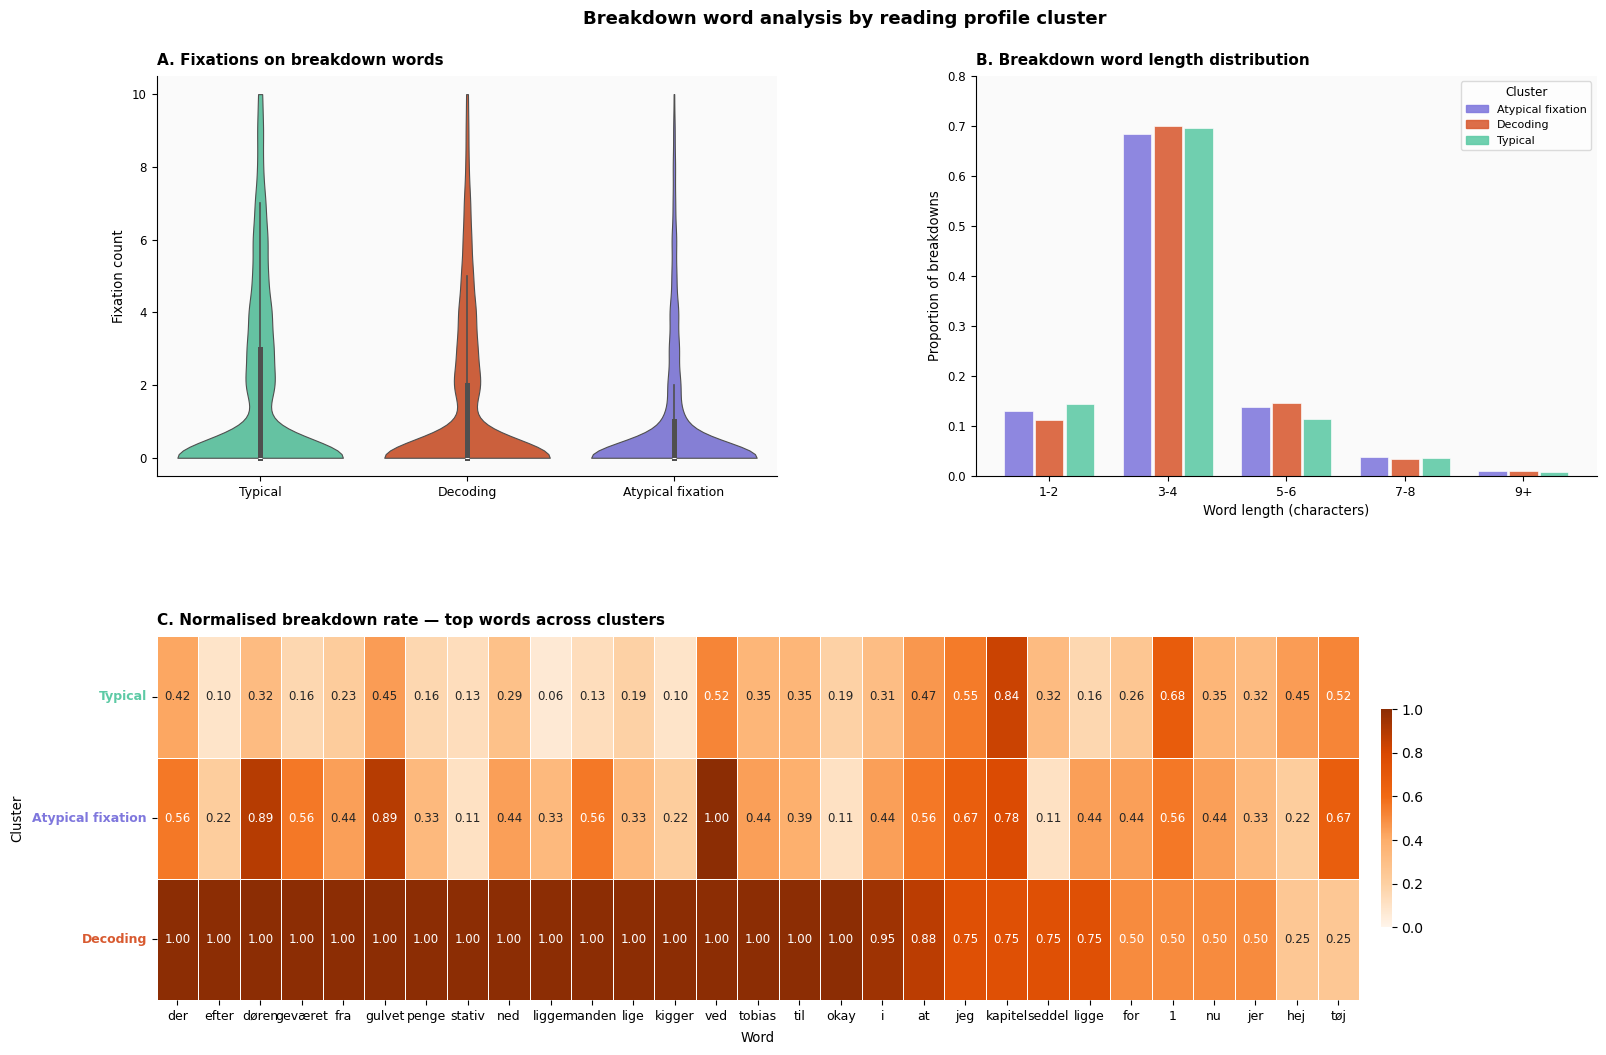

Saved: breakdown_analysis.png


In [48]:
# BREAKDOWN WORD ANALYSIS — summary figure

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

COLORS = {
    "Typical":           "#5DCAA5",
    "Atypical fixation": "#7F77DD",
    "Decoding":          "#D85A30",
}

cluster_order = ["Typical", "Decoding", "Atypical fixation"]
bar_order     = ["Atypical fixation", "Decoding", "Typical"]


fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor("white")

gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    height_ratios=[1.1, 1],
    hspace=0.42,
    wspace=0.32,
    left=0.07, right=0.97,
    top=0.91, bottom=0.07,
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

# Panel A: Violin plot of fixations on breakdown words 
violin_df = (
    breakdowns_df[breakdowns_df["n_fixations_on_word"] <= 10]
    [["ClusterLabel", "n_fixations_on_word"]]
    .rename(columns={"n_fixations_on_word": "Fixation count",
                     "ClusterLabel": "Cluster"})
)

sns.violinplot(
    data=violin_df,
    x="Cluster", y="Fixation count",
    order=cluster_order,
    hue="Cluster",
    palette=COLORS,
    legend=False,
    ax=ax_a,
    inner="box",
    cut=0,
    linewidth=0.8,
    saturation=0.85,
)

ax_a.set_title("A. Fixations on breakdown words",
               fontsize=11, fontweight="bold", pad=8, loc="left")
ax_a.set_xlabel("")
ax_a.set_ylabel("Fixation count", fontsize=9.5)
ax_a.set_ylim(-0.5, 10.5)
ax_a.tick_params(axis="x", labelsize=9)
ax_a.tick_params(axis="y", labelsize=8.5)
ax_a.spines[["top", "right"]].set_visible(False)
ax_a.set_facecolor("#FAFAFA")

# Panel B: Grouped bar plot of word length distribution 
length_profile = (
    breakdowns_df.groupby(["ClusterLabel", "length_bin"], observed=True)
    .size()
    .unstack(fill_value=0)
)
length_pct = length_profile.div(length_profile.sum(axis=1), axis=0)

x     = np.arange(len(length_pct.columns))
width = 0.26
offsets = {"Atypical fixation": -width, "Decoding": 0, "Typical": width}

for label in bar_order:
    ax_b.bar(
        x + offsets[label],
        length_pct.loc[label],
        width=width * 0.92,
        color=COLORS[label],
        label=label,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.88,
    )

ax_b.set_title("B. Breakdown word length distribution",
               fontsize=11, fontweight="bold", pad=8, loc="left")
ax_b.set_xlabel("Word length (characters)", fontsize=9.5)
ax_b.set_ylabel("Proportion of breakdowns", fontsize=9.5)
ax_b.set_xticks(x)
ax_b.set_xticklabels(length_pct.columns, fontsize=9)
ax_b.tick_params(axis="y", labelsize=8.5)
ax_b.set_ylim(0, 0.80)
ax_b.spines[["top", "right"]].set_visible(False)
ax_b.set_facecolor("#FAFAFA")
ax_b.legend(
    handles=[mpatches.Patch(color=COLORS[l], label=l, alpha=0.88)
             for l in bar_order],
    title="Cluster", title_fontsize=8.5, fontsize=8,
    frameon=True, framealpha=0.7, edgecolor="#CCCCCC",
    loc="upper right",
)

# Panel C: Heatmap plot of normalised breakdown rates
# Build heatmap from the normalised rate data already computed above
heatmap_data = {}
for label in ["Typical", "Atypical fixation", "Decoding"]:
    cluster_df        = breakdowns_df[breakdowns_df["ClusterLabel"] == label]
    n_students_in_cluster        = cluster_df["UserId"].nunique()
    counts            = cluster_df[word_col].str.lower().value_counts()
    expected          = word_freq * n_students_in_cluster
    rate              = (counts / expected).dropna().clip(upper=1.0)
    heatmap_data[label] = rate

heatmap_df = pd.DataFrame(heatmap_data)

# Keep only words appearing in the top 15 of at least one cluster
top_words = set()
for label in ["Typical", "Atypical fixation", "Decoding"]:
    top_words.update(heatmap_df[label].nlargest(15).index.tolist())

heatmap_df = (
    heatmap_df.loc[heatmap_df.index.isin(top_words)]
    .fillna(0)
    .sort_values("Decoding", ascending=False)
    .T
    .loc[["Typical", "Atypical fixation", "Decoding"]]
)

cmap = LinearSegmentedColormap.from_list(
    "breakdown",
    ["#FFF5EB", "#FDD0A2", "#FDAE6B", "#F16913", "#D94801", "#8C2D04"],
    N=256,
)

sns.heatmap(
    heatmap_df,
    ax=ax_c,
    cmap=cmap,
    vmin=0, vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8.5},
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"shrink": 0.6, "pad": 0.015,
              "ticks": [0, 0.2, 0.4, 0.6, 0.8, 1.0]},
)

ax_c.set_title(
    "C. Normalised breakdown rate — top words across clusters",
    fontsize=11, fontweight="bold", pad=8, loc="left",
)
ax_c.set_xlabel("Word", fontsize=9.5, labelpad=6)
ax_c.set_ylabel("Cluster", fontsize=9.5, labelpad=6)
ax_c.tick_params(axis="x", labelsize=9, rotation=0)
ax_c.tick_params(axis="y", labelsize=9, rotation=0)

for tick_label in ax_c.get_yticklabels():
    tick_label.set_color(COLORS.get(tick_label.get_text(), "black"))
    tick_label.set_fontweight("bold")
    
# Supertitle
fig.suptitle(
    "Breakdown word analysis by reading profile cluster",
    fontsize=13, fontweight="bold", y=0.97,
)

# Remove plt.tight_layout() — margins handled by GridSpec
plt.savefig("breakdown_analysis.png", dpi=180, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved: breakdown_analysis.png")

In [49]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [50]:
!pip install scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


=== Pairwise Mann-Whitney U: fixations on breakdown words ===

Typical vs Atypical fixation: U=2568651, p=0.0000 ***, r=0.175
Typical vs Decoding: U=2960535, p=0.0000 ***, r=0.094
Atypical fixation vs Decoding: U=979410, p=0.0000 ***, r=0.103


/tmp/ipykernel_832/1285338989.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x="ClusterLabel", y="n_fixations_on_word",
/tmp/ipykernel_832/1285338989.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_a.set_xticklabels(ax_a.get_xticklabels(), rotation=15, ha="right")


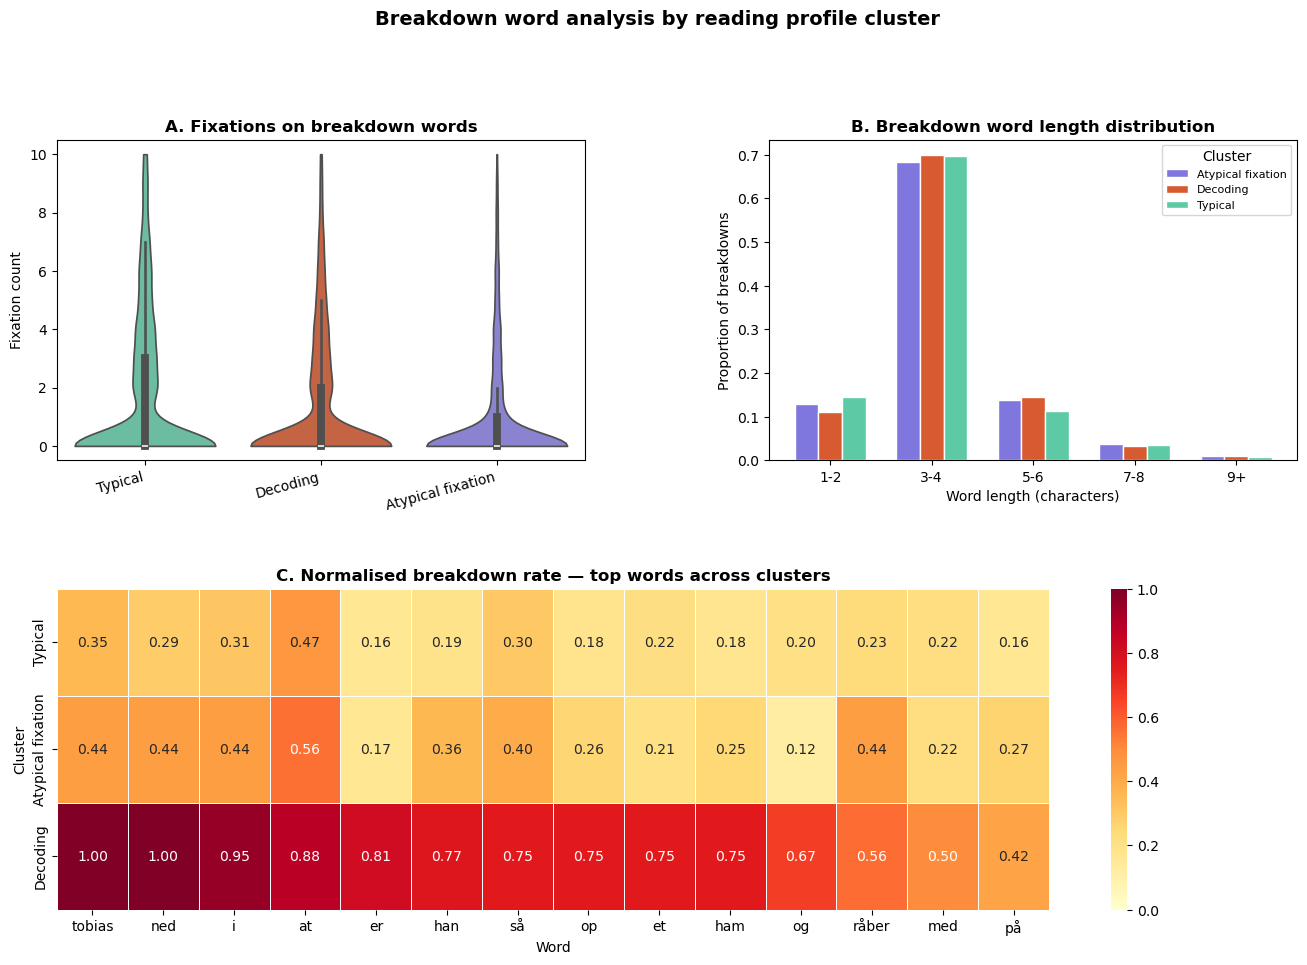

Saved: breakdown_analysis.png


In [51]:
# Fix FutureWarning and produce summary visualisation

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import mannwhitneyu

# Fix: add observed=True to all groupby calls with categorical columns
length_profile = (
    breakdowns_df.groupby(["ClusterLabel", "length_bin"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Pairwise post-hoc for fixations on breakdown words 
print("=== Pairwise Mann-Whitney U: fixations on breakdown words ===\n")
cluster_labels_list = ["Typical", "Atypical fixation", "Decoding"]
fix_col = "n_fixations_on_word"

for c1, c2 in itertools.combinations(cluster_labels_list, 2):
    g1 = breakdowns_df[breakdowns_df["ClusterLabel"] == c1][fix_col].dropna()
    g2 = breakdowns_df[breakdowns_df["ClusterLabel"] == c2][fix_col].dropna()
    u_stat, p_val = mannwhitneyu(g1, g2, alternative="two-sided")
    
    # Effect size r = Z / sqrt(N)
    import scipy.stats as scipy_stats
    z = scipy_stats.norm.ppf(p_val / 2)
    r = abs(z) / np.sqrt(len(g1) + len(g2))
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 \
          else "*" if p_val < 0.05 else "ns"
    print(f"{c1} vs {c2}: U={u_stat:.0f}, p={p_val:.4f} {sig}, r={r:.3f}")

# Summary figure
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

colors = {"Typical": "#5DCAA5", 
          "Atypical fixation": "#7F77DD", 
          "Decoding": "#D85A30"}

# Panel A: Fixations on breakdown words (violin)
ax_a = fig.add_subplot(gs[0, 0])
plot_data = breakdowns_df[breakdowns_df["n_fixations_on_word"] <= 10].copy()
sns.violinplot(data=plot_data, x="ClusterLabel", y="n_fixations_on_word",
               palette=colors, ax=ax_a, inner="box", cut=0)
ax_a.set_title("A. Fixations on breakdown words", fontweight="bold")
ax_a.set_xlabel("")
ax_a.set_ylabel("Fixation count")
ax_a.set_xticklabels(ax_a.get_xticklabels(), rotation=15, ha="right")

# Panel B: Word length distribution
ax_b = fig.add_subplot(gs[0, 1])
length_pct = length_profile.div(length_profile.sum(axis=1), axis=0)
length_pct.T.plot(kind="bar", ax=ax_b,
                  color=[colors[c] for c in length_pct.index],
                  edgecolor="white", width=0.7)
ax_b.set_title("B. Breakdown word length distribution", fontweight="bold")
ax_b.set_xlabel("Word length (characters)")
ax_b.set_ylabel("Proportion of breakdowns")
ax_b.legend(title="Cluster", fontsize=8)
ax_b.tick_params(axis="x", rotation=0)

# Panel C: Top breakdown words heatmap
# Normalised rate for top 10 words shared across clusters
ax_c = fig.add_subplot(gs[1, :])

all_top_words = set()
for label in cluster_labels_list:
    cluster_df  = breakdowns_df[breakdowns_df["ClusterLabel"] == label]
    n_students_in_cluster  = cluster_df["UserId"].nunique()
    counts      = cluster_df[word_col].str.lower().value_counts()
    expected    = word_freq * n_students_in_cluster
    rate        = (counts / expected).dropna().clip(upper=1.0)
    top         = rate[rate.index.isin(
                       word_freq[word_freq >= 3].index
                  )].nlargest(10).index.tolist()
    all_top_words.update(top)

heatmap_data = {}
for label in cluster_labels_list:
    cluster_df = breakdowns_df[breakdowns_df["ClusterLabel"] == label]
    n_students_in_cluster = cluster_df["UserId"].nunique()
    counts   = cluster_df[word_col].str.lower().value_counts()
    expected = word_freq * n_students_in_cluster
    rate     = (counts / expected).dropna().clip(upper=1.0)
    heatmap_data[label] = rate.reindex(all_top_words).fillna(0)

heatmap_df = pd.DataFrame(heatmap_data).sort_values("Decoding", ascending=False)
sns.heatmap(heatmap_df.T, cmap="YlOrRd", annot=True, fmt=".2f",
            linewidths=0.5, ax=ax_c, vmin=0, vmax=1)
ax_c.set_title("C. Normalised breakdown rate — top words across clusters",
               fontweight="bold")
ax_c.set_xlabel("Word")
ax_c.set_ylabel("Cluster")

plt.suptitle("Breakdown word analysis by reading profile cluster",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("breakdown_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: breakdown_analysis.png")

In [56]:
# STATISTICAL TEST: Fixations on breakdown words
# Kruskal-Wallis + pairwise Mann-Whitney U with effect sizes

from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
import numpy as np
import pandas as pd

fix_col       = "n_fixations_on_word"
cluster_order = ["Typical", "Atypical fixation", "Decoding"]

# Extract group data
groups = {
    label: breakdowns_df[breakdowns_df["ClusterLabel"] == label]
           [fix_col].dropna().values
    for label in cluster_order
}

# Overall Kruskal-Wallis
h_stat, p_val = kruskal(*groups.values())
print("=== Kruskal-Wallis test ===")
print(f"H = {h_stat:.3f}, p = {p_val:.4f}")
print("Interpretation: tests whether at least one cluster differs")
print()

# Pairwise Mann-Whitney U with effect size r 
# Effect size r = Z / sqrt(N) where Z is derived from U statistic
# Conventions: r > 0.1 small, r > 0.3 medium, r > 0.5 large
# Bonferroni correction for 3 pairwise tests: p < 0.05/3 = 0.0167

n_comparisons   = 3
bonf_threshold  = 0.05 / n_comparisons
print(f"=== Pairwise Mann-Whitney U (Bonferroni threshold: "
      f"p < {bonf_threshold:.4f}) ===\n")

pairwise_results = []

for (label1, label2) in combinations(cluster_order, 2):
    g1 = groups[label1]
    g2 = groups[label2]
    n1 = len(g1)
    n2 = len(g2)

    u_stat, p_mw = mannwhitneyu(g1, g2, alternative="two-sided")

    # Effect size r = Z / sqrt(N)
    # Z approximated from U statistic
    mean_u = n1 * n2 / 2
    std_u  = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z      = (u_stat - mean_u) / std_u
    r      = abs(z) / np.sqrt(n1 + n2)

    # Magnitude
    if r >= 0.5:
        magnitude = "large"
    elif r >= 0.3:
        magnitude = "medium"
    else:
        magnitude = "small"

    # Significance after Bonferroni
    if p_mw < 0.001:
        sig = "***"
    elif p_mw < 0.01:
        sig = "**"
    elif p_mw < bonf_threshold:
        sig = "*"
    else:
        sig = "ns"

    pairwise_results.append({
        "Comparison":       f"{label1} vs {label2}",
        "n1":               n1,
        "n2":               n2,
        "Mean 1":           round(g1.mean(), 3),
        "Mean 2":           round(g2.mean(), 3),
        "U statistic":      round(u_stat, 1),
        "Z":                round(z, 3),
        "p (two-tailed)":   round(p_mw, 4),
        "Sig (Bonf.)":      sig,
        "Effect size r":    round(r, 3),
        "Magnitude":        magnitude,
    })

    print(f"{label1} (M={g1.mean():.3f}) vs "
          f"{label2} (M={g2.mean():.3f})")
    print(f"  U={u_stat:.1f}, Z={z:.3f}, "
          f"p={p_mw:.4f} {sig}, r={r:.3f} ({magnitude})")
    print()

pairwise_df = pd.DataFrame(pairwise_results)

# Descriptive summary table
print("=== Descriptive summary ===\n")
desc = breakdowns_df.groupby("ClusterLabel")[fix_col].agg(
    n="count",
    Mean="mean",
    Median="median",
    SD="std",
    Q25=lambda x: x.quantile(0.25),
    Q75=lambda x: x.quantile(0.75),
).round(3)
print(desc.to_string())
print()

# Interpretation note 
print("=== Interpretation ===")
print(f"Kruskal-Wallis confirmed a significant overall difference "
      f"(H={h_stat:.2f}, p<.001).")
print(f"All three pairwise comparisons are significant after "
      f"Bonferroni correction (p < {bonf_threshold:.4f}).")
print("Note: medians are all 0 across groups — the mean difference")
print("is driven by the upper tail (students who DO re-read).")
print("Effect sizes reflect the distributional shift in re-reading")
print("attempts, not a shift in typical behaviour.")

# Save
pairwise_df.to_excel("fixation_breakdown_stats.xlsx",
                      index=False, engine="openpyxl")
print("\nSaved: fixation_breakdown_stats.xlsx")

=== Kruskal-Wallis test ===
H = 153.370, p = 0.0000
Interpretation: tests whether at least one cluster differs

=== Pairwise Mann-Whitney U (Bonferroni threshold: p < 0.0167) ===

Typical (M=2.394) vs Atypical fixation (M=1.008)
  U=2568651.0, Z=10.399, p=0.0000 ***, r=0.154 (small)

Typical (M=2.394) vs Decoding (M=1.529)
  U=2960535.0, Z=5.833, p=0.0000 ***, r=0.083 (small)

Atypical fixation (M=1.008) vs Decoding (M=1.529)
  U=979409.5, Z=-4.627, p=0.0000 ***, r=0.085 (small)

=== Descriptive summary ===

                      n   Mean  Median     SD  Q25  Q75
ClusterLabel                                           
Atypical fixation  1318  1.008     0.0  2.268  0.0  1.0
Decoding           1649  1.529     0.0  2.902  0.0  2.0
Typical            3259  2.394     0.0  4.700  0.0  4.0

=== Interpretation ===
Kruskal-Wallis confirmed a significant overall difference (H=153.37, p<.001).
All three pairwise comparisons are significant after Bonferroni correction (p < 0.0167).
Note: medians a

In [57]:
# TABLE: Statistical results — fixations on breakdown words


import pandas as pd
import numpy as np
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

fix_col       = "n_fixations_on_word"
cluster_order = ["Typical", "Atypical fixation", "Decoding"]

groups = {
    label: breakdowns_df[breakdowns_df["ClusterLabel"] == label]
           [fix_col].dropna().values
    for label in cluster_order
}

# Part 1: Descriptive statistics table 
desc_rows = []
for label in cluster_order:
    vals = groups[label]
    nonzero     = (vals > 0).sum()
    nonzero_pct = nonzero / len(vals) * 100
    desc_rows.append({
        "Cluster":              label,
        "N (breakdown events)": len(vals),
        "Mean (SD)":            f"{vals.mean():.2f} ({vals.std():.2f})",
        "Median":               f"{np.median(vals):.2f}",
        "Q25 – Q75":            f"{np.percentile(vals,25):.2f} – "
                                f"{np.percentile(vals,75):.2f}",
        "Max":                  int(vals.max()),
        "Non-zero (%)":         f"{nonzero} ({nonzero_pct:.1f}%)",
    })

desc_df = pd.DataFrame(desc_rows)

print("=" * 70)
print("TABLE A: Descriptive statistics — fixations on breakdown words")
print("=" * 70)
print(desc_df.to_string(index=False))


# Part 2: Inferential statistics table 
h_stat, p_kw = kruskal(*groups.values())

n_comparisons  = 3
bonf_threshold = 0.05 / n_comparisons

pairwise_rows = []
for (label1, label2) in combinations(cluster_order, 2):
    g1 = groups[label1]
    g2 = groups[label2]
    n1, n2 = len(g1), len(g2)

    u_stat, p_mw = mannwhitneyu(g1, g2, alternative="two-sided")

    # Effect size r
    mean_u = n1 * n2 / 2
    std_u  = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z      = (u_stat - mean_u) / std_u
    r      = abs(z) / np.sqrt(n1 + n2)

    if r >= 0.5:
        magnitude = "large"
    elif r >= 0.3:
        magnitude = "medium"
    else:
        magnitude = "small"

    if p_mw < 0.001:
        sig = "***"
    elif p_mw < 0.01:
        sig = "**"
    elif p_mw < bonf_threshold:
        sig = "*"
    else:
        sig = "ns"

    pairwise_rows.append({
        "Comparison":     f"{label1} vs {label2}",
        "U":              f"{u_stat:.1f}",
        "Z":              f"{z:.3f}",
        "p (two-tailed)": f"{p_mw:.2e}",
        "Sig. (Bonf.)":   sig,
        "r":              f"{r:.3f}",
        "Magnitude":      magnitude,
    })

pairwise_df = pd.DataFrame(pairwise_rows)

print()
print("=" * 70)
print("TABLE B: Kruskal-Wallis and pairwise Mann-Whitney U results")
print("=" * 70)
print(f"Overall Kruskal-Wallis: H = {h_stat:.3f}, p < .001\n")
print(pairwise_df.to_string(index=False))
print(f"\nNote: Bonferroni-corrected significance threshold: "
      f"p < {bonf_threshold:.4f} (0.05 / {n_comparisons} comparisons).")
print("Effect size r: small > 0.1, medium > 0.3, large > 0.5 "
      "(Cohen, 1988).")
print("Effect sizes are attenuated by zero-inflation in the "
      "fixation count distribution (Conover & Iman, 1981).")


# Part 3: Non-zero proportion comparison
nonzero_rows = []
for label in cluster_order:
    vals        = groups[label]
    nonzero     = (vals > 0).sum()
    nonzero_pct = nonzero / len(vals) * 100
    mean_nonzero = vals[vals > 0].mean() if nonzero > 0 else 0
    nonzero_rows.append({
        "Cluster":                    label,
        "Total breakdown events":     len(vals),
        "Events with re-reading (n)": nonzero,
        "Events with re-reading (%)": f"{nonzero_pct:.1f}%",
        "Mean fixations | re-reading":f"{mean_nonzero:.2f}",
    })

nonzero_df = pd.DataFrame(nonzero_rows)

print()
print("=" * 70)
print("TABLE C: Re-reading attempts — non-zero breakdown events only")
print("=" * 70)
print(nonzero_df.to_string(index=False))
print("\nNote: 'Mean fixations | re-reading' = mean fixation count "
      "conditional on at least one re-reading fixation occurring.")


# Save all three tables to one Excel file
with pd.ExcelWriter("fixation_breakdown_tables.xlsx",
                    engine="openpyxl") as writer:
    desc_df.to_excel(    writer, sheet_name="A_Descriptive",  index=False)
    pairwise_df.to_excel(writer, sheet_name="B_Inferential",  index=False)
    nonzero_df.to_excel( writer, sheet_name="C_NonZero",      index=False)

print("\nSaved: fixation_breakdown_tables.xlsx "
      "(sheets: A_Descriptive, B_Inferential, C_NonZero)")

TABLE A: Descriptive statistics — fixations on breakdown words
          Cluster  N (breakdown events)   Mean (SD) Median   Q25 – Q75  Max Non-zero (%)
          Typical                  3259 2.39 (4.70)   0.00 0.00 – 4.00   92 1417 (43.5%)
Atypical fixation                  1318 1.01 (2.27)   0.00 0.00 – 1.00   16  359 (27.2%)
         Decoding                  1649 1.53 (2.90)   0.00 0.00 – 2.00   41  585 (35.5%)

TABLE B: Kruskal-Wallis and pairwise Mann-Whitney U results
Overall Kruskal-Wallis: H = 153.370, p < .001

                   Comparison         U      Z p (two-tailed) Sig. (Bonf.)     r Magnitude
 Typical vs Atypical fixation 2568651.0 10.399       2.09e-32          *** 0.154     small
          Typical vs Decoding 2960535.0  5.833       5.46e-11          *** 0.083     small
Atypical fixation vs Decoding  979409.5 -4.627       2.12e-08          *** 0.085     small

Note: Bonferroni-corrected significance threshold: p < 0.0167 (0.05 / 3 comparisons).
Effect size r: small >

In [52]:
# FINAL: Assign intervention group labels and export

final_labels = pd.Series("", index=features_clean.index, name="InterventionGroup")

# Typical group: k=2 split by PC2 + PC4 
CHOSEN_K_C0 = 2
gmm_c0 = GaussianMixture(n_components=CHOSEN_K_C0, n_init=50, random_state=42)
sub_labels_c0 = gmm_c0.fit(X_c0).predict(X_c0)

c0_profile = pd.DataFrame({
    "sub": sub_labels_c0,
    "PC2": X_c0[:, 0],
    "PC4": X_c0[:, 1]
})
c0_means = c0_profile.groupby("sub")[["PC2", "PC4"]].mean()
print("Typical subgroup means (PC2=cognitive load, PC4=fluency):")
print(c0_means.round(2))

# Higher PC4 = more fluent
fluent_sub  = int(c0_means["PC4"].idxmax())
effortful_sub = int(c0_means["PC4"].idxmin())

subgroup_names_c0 = {
    fluent_sub:   "Typical — fluent",
    effortful_sub: "Typical — effortful pace",
}

for i, user in enumerate(c0_idx):
    final_labels[user] = subgroup_names_c0[sub_labels_c0[i]]

# Low engagement group: k=2 split by PC3 
CHOSEN_K_C2 = 2
X_c2 = pca_df.loc[c2_idx, ["PC3"]].values

gmm_c2 = GaussianMixture(n_components=CHOSEN_K_C2, n_init=50, random_state=42)
sub_labels_c2 = gmm_c2.fit(X_c2).predict(X_c2)

c2_profile = pd.DataFrame({
    "sub": sub_labels_c2,
    "PC3": X_c2[:, 0]
})
c2_means = c2_profile.groupby("sub")["PC3"].mean()
print("\nLow engagement subgroup means (PC3=eye movement efficiency):")
print(c2_means.round(2))

# Higher PC3 = more regressions = more active re-reading attempts
active_sub  = int(c2_means.idxmax())
passive_sub = int(c2_means.idxmin())

subgroup_names_c2 = {
    active_sub:  "Atypical eye movement — active re-reader",
    passive_sub: "Atypical eye movement — passive/disengaged",
}

for i, user in enumerate(c2_idx):
    final_labels[user] = subgroup_names_c2[sub_labels_c2[i]]

# Decoding group: no sub-clustering 
for user in c1_idx:
    final_labels[user] = "Decoding difficulty — review individually"

# Build and export final output 
top_level_map = {
    typical_cluster:    "Typical",
    decoding_cluster:   "Decoding difficulty",
    low_engage_cluster: "Atypical eye movement",
}

sep_series = pd.Series(separation_ratio,
                       index=features_clean.index,
                       name="separation_ratio")

output = pd.DataFrame({
    "UserId":            features_clean.index,
    "TopLevelCluster":   pd.Series(cluster_labels,
                                   index=features_clean.index).map(top_level_map),
    "InterventionGroup": final_labels,
    "separation_ratio":  sep_series.round(2),
    "needs_review":      (sep_series < 1.5),
})

print("\n=== Final intervention group counts ===")
print(output["InterventionGroup"].value_counts())

output.to_excel("intervention_groups_final.xlsx", index=False, engine="openpyxl")
print("\nSaved: intervention_groups_final.xlsx")

NameError: name 'X_c0' is not defined

In [54]:
# FINAL CLEAN EXPORT: 3 intervention groups

top_level_map = {
    typical_cluster:    "Typical readers",
    decoding_cluster:   "Decoding difficulty — review individually",
    atypical_cluster: "Atypical reading pattern — review individually",
}

sep_series = pd.Series(separation_ratio,
                       index=features_clean.index,
                       name="separation_ratio")

output = pd.DataFrame({
    "UserId":            features_clean.index,
    "InterventionGroup": pd.Series(cluster_labels,
                                   index=features_clean.index).map(top_level_map),
    "separation_ratio":  sep_series.round(2),
    "needs_review":      (sep_series < 1.5),
})

# Add key raw features for teacher reference
key_features = ["word_accuracy", "words_per_minute", "fixation_count",
                "retranscription_rate", "silence_rate"]
output = output.join(features_clean[key_features].round(2))

print("=== Final intervention group counts ===")
print(output["InterventionGroup"].value_counts())
print(f"\nStudents flagged for individual review: {output['needs_review'].sum()}")

output.to_excel("intervention_groups_final.xlsx", index=False, engine="openpyxl")
print("\nSaved: intervention_groups_final.xlsx")

KeyError: "['fixation_count'] not in index"